# Shadows of Transparency

This notebook includes the code used for the analyses presented in the paper “Shadows of Transparency: Assessing Government Transparency Using Public Data” (in preparation). The work builds on the Woogle dataset and its accompanying notebook [1]. The dataset is available through DANS [2].

<small>[1] van Heusden, R., Larooij, M., Kamps, J. et al. A collection of FAIR Dutch Freedom of Information Act documents. Sci Data 12, 795 (2025). https://doi.org/10.1038/s41597-025-05052-2</small> <br>
<small>[2] M. Marx, 2023, "A collection of FAIR Dutch Freedom of Information Act documents", https://doi.org/10.17026/DANS-ZAU-E3RK, DANS Data Station Social Sciences and Humanities, V4 </small>

## Transparency Anti-Patterns
We implemented six indicators corresponding to transparency anti-patterns.


<img src="antipatterns-1.png" alt="Antipatterns" width="40%">

In [9]:
# Imports
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

tqdm.pandas()

%matplotlib inline

## Dataset loading

First, we load the dataset. This may take a while.

In [ ]:
# manually set the correct types for all three dataframes
bodytext_dtypes = {'foi_pageNumber': 'Int64',
                   'foi_bodyText': str,
                   'foi_bodyTextOCR': str,
                   'foi_hasOCR': 'boolean',
                   'foi_redacted': 'boolean',
                   'foi_contourArea': float,
                   'foi_textArea': float,
                   'foi_charArea': float,
                   'foi_percentageTextAreaRedacted': float,
                   'foi_percentageCharAreaRedacted': float,
                   'foi_dossierType': str,
                   'foi_bodyTextJaccard': float,
                   'foi_imageArea': float,
                   'foi_imageCoversFullPage': 'boolean',
                   'foi_isFirstPageOfNewDoc': object,
                   'foi_nrRedactedRegions': 'Int64'}

document_dtypes = {'dc_identifier': str,
                   'dc_title': str,
                   'foi_fileName': str,
                   'dc_format': str,
                   'dc_source': str,
                   'dc_type': str,
                   'foi_nrPages': float,
                   'dc_description': str,
                   'foi_fairiscoreVersions': str,
                   'foi_pdfAuthor': str,
                   'foi_pdfCompany': str,
                   'foi_pdfCreator': str,
                   'foi_pdfDateCreated': str,
                   'foi_pdfDateModified': str,
                   'foi_pdfKeywords': str,
                   'foi_pdfProducer': str,
                   'foi_pdfSubject': str,
                   'foi_pdfTitle': str}

dossier_dtypes = {'dc_title': str,
                  'dc_description': str,
                  'dc_type': str,
                  'dc_publisher_name': str,
                  'dc_publisher': str,
                  'dc_source': str,
                  'foi_valuation': str,
                  'foi_requestText': str,
                  'foi_decisionText': str,
                  'foi_isAdjourned': str,
                  'foi_requester': str,
                  'dc_date_year': 'Int64',
                  'dc_type_description': str,
                  'foi_decisionDate': str,
                  'foi_geoInfo': str,
                  'foi_publishedDate': str,
                  'foi_requestDate': str,
                  'foi_retrievedDate': str,
                  'tooiwl_rubriek': str,
                  'tooiwl_rubriekCode': str}

In [3]:
DATAFRAME_FOLDER = 'data' # Replace this with the correct path for your situation
bodytext_dataframe = pd.read_csv(os.path.join(DATAFRAME_FOLDER, 'woo_bodytext_2i.csv.gz'), dtype=bodytext_dtypes).set_index('foi_documentId')

document_dataframe = pd.read_csv(os.path.join(DATAFRAME_FOLDER, 'woo_documents.csv.gz'), dtype=document_dtypes).set_index('foi_dossierId')

dossier_dataframe = pd.read_csv(os.path.join(DATAFRAME_FOLDER, 'woo_dossiers.csv.gz'), parse_dates=['foi_publishedDate', 'foi_requestDate',
                                                                                'foi_decisionDate', 'foi_retrievedDate'], dtype=dossier_dtypes).set_index('dc_identifier')

# convert the firstpageofnewdoc to a proper boolean column, currently its in a bytes format
bodytext_dataframe.foi_isFirstPageOfNewDoc = bodytext_dataframe.foi_isFirstPageOfNewDoc.apply(lambda x: ord(eval(x)) if isinstance(x, str) else np.nan)
bodytext_dataframe.foi_isFirstPageOfNewDoc = bodytext_dataframe.foi_isFirstPageOfNewDoc.astype('boolean')

#Filter the dossiers and documents to only have the category of passively released documents
dossier_dataframe = dossier_dataframe[dossier_dataframe['dc_type'] == '2i']
document_dataframe = document_dataframe[document_dataframe.index.fillna("").str.contains('2i')]

To make the processing of the dataset easier, we will join all three dataframes, so that we can combine the statistics of the three dataframes for interesting statistics. We will join the dataframes using the document identifier as the primary key. This will result in the document number of a page being the index into the dataframe.

In [6]:
dossier_and_document_dataframe = document_dataframe.join(dossier_dataframe, rsuffix="_dossier")
assert dossier_and_document_dataframe.shape[0] == document_dataframe.shape[0]
dossier_and_document_dataframe = dossier_and_document_dataframe.reset_index().set_index('dc_identifier')
dossier_and_document_dataframe.rename({'index': 'foi_dossierId'}, inplace=True, axis=1)
complete_dataframe = bodytext_dataframe.join(dossier_and_document_dataframe)
assert complete_dataframe.shape[0] == bodytext_dataframe.shape[0]

In [5]:
translation_dict = {
    'Ministerie Van Algemene Zaken': 'Min AZ',
    'Ministerie Van Buitenlandse Zaken': 'Min BZ',
    'Ministerie Van Defensie': 'Min DEF',
    'Ministerie Van Volksgezondheid, Welzijn En Sport': 'Min VWS',
    'Ministerie Van Binnenlandse Zaken En Koninkrijksrelaties':  'Min BZK',
    'Ministerie van Economische Zaken': 'Min EZK',
    'Ministerie Van Justitie En Veiligheid': 'Min J&V',
    'Ministerie Van Sociale Zaken En Werkgelegenheid':  'Min SZW',
    'Ministerie Van Financiën':  'Min FIN',
    'Ministerie Van Onderwijs, Cultuur En Wetenschap': 'Min OCW',
    'Ministerie Van Infrastructuur En Waterstaat' : 'Min I&W',
    'Ministerie van Landbouw, Visserij, Voedselzekerheid en Natuur':  'Min LVVN',
    'Ministerie van Asiel en Migratie': 'Min A&M',
    'Ministerie van Volkshuisvesting en Ruimtelijke Ordening': 'Min VRO',
    'Ministerie van Klimaat en Groene Groei': 'Min KGG'
}

## General statistics

In [7]:
num_dossiers = complete_dataframe.foi_dossierId.nunique()
num_documents = complete_dataframe.index.nunique()
num_pages = complete_dataframe.shape[0]
print(f"The dataset contains {num_dossiers:,d} dossiers, {num_documents:,d} documents, and {num_pages:,d} pages")

The dataset contains 15,277 dossiers, 139,449 documents, and 2,644,696 pages


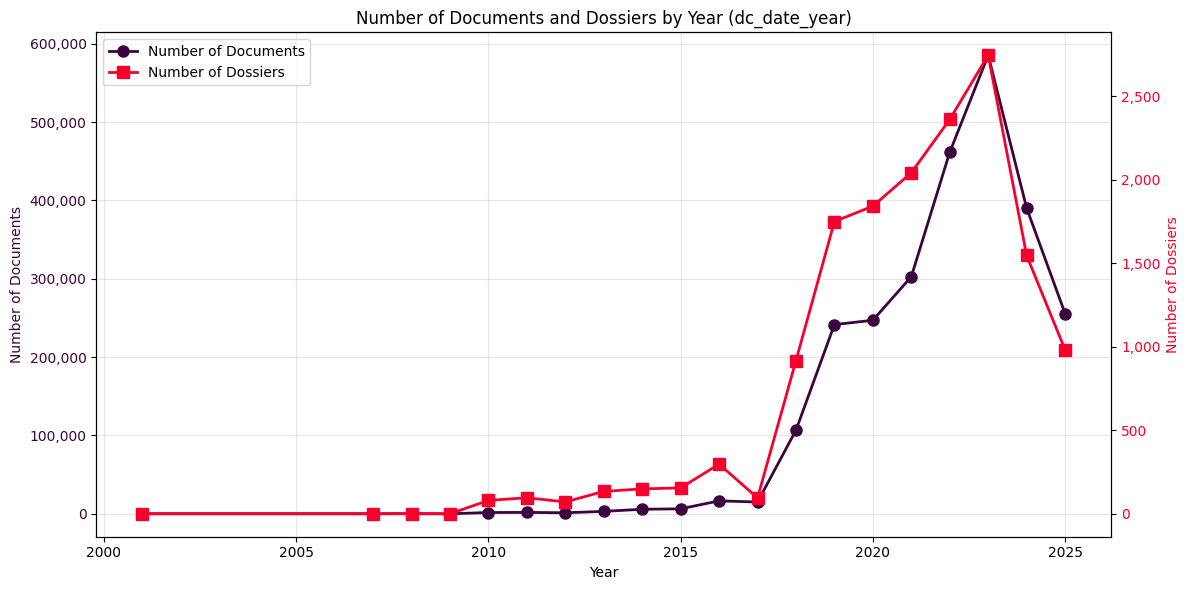

In [ ]:
# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Calculate documents and dossiers per year using dc_date_year
docs_by_year = complete_dataframe.groupby(complete_dataframe['dc_date_year']).size()
dossiers_by_year = complete_dataframe.groupby(complete_dataframe['dc_date_year'])['foi_dossierId'].nunique()

# Plot number of documents on primary y-axis
palette_color = [np.array([60, 4, 62])/255, np.array([125, 0, 85])/255, np.array([191, 0, 83])/255, np.array([247, 0, 46])/255, np.array([255, 103, 60])/255, np.array([255, 178, 138])/255]
color1 = palette_color[0]
ax1.plot(docs_by_year.index, docs_by_year.values, marker='o', color=color1, linewidth=2, markersize=8, label='Number of Documents')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Documents', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax1.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Create secondary y-axis for dossiers
ax2 = ax1.twinx()
color2 = palette_color[3]
ax2.plot(dossiers_by_year.index, dossiers_by_year.values, marker='s', color=color2, linewidth=2, markersize=8, label='Number of Dossiers')
ax2.set_ylabel('Number of Dossiers', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.get_yaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add title and legends
plt.title('Number of Documents and Dossiers by Year')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## Anti-patterns
Indicators blabla



#### Narrow / Overbroad Reading

##### Local values

In [120]:
import pandas as pd
import numpy as np

# ---------------------------------------------------
# 1. Dossier sizes per ministry / dossier / year
# ---------------------------------------------------
dossier_sizes_by_ministry_year = (
    complete_dataframe
    .groupby(['dc_publisher_name', 'foi_dossierId', 'dc_date_year'])['foi_pageNumber']
    .count()
    .reset_index()
)

dossier_sizes_by_ministry_year.columns = ['dc_publisher_name', 'foi_dossierId', 'year', 'num_pages']

# ---------------------------------------------------
# 2. Translate ministry names to short labels & keep ministries only
# ---------------------------------------------------
# Map long → short
dossier_sizes_by_ministry_year['dc_publisher_name'] = (
    dossier_sizes_by_ministry_year['dc_publisher_name']
    .map(translation_dict)
    .fillna(dossier_sizes_by_ministry_year['dc_publisher_name'])
)

# Keep only ministries present in translation_dict values
valid_ministries = list(translation_dict.values())
dossier_sizes_by_ministry_year = dossier_sizes_by_ministry_year[
    dossier_sizes_by_ministry_year['dc_publisher_name'].isin(valid_ministries)
]

# ---------------------------------------------------
# 3. Local 5th / 95th percentiles per ministry
# ---------------------------------------------------
local_percentiles = (
    dossier_sizes_by_ministry_year
    .groupby('dc_publisher_name')['num_pages']
    .quantile([0.05, 0.95])
    .unstack()
    .rename(columns={0.05: 'local_p5', 0.95: 'local_p95'})
)

# Merge thresholds back onto each dossier
df_local = dossier_sizes_by_ministry_year.merge(
    local_percentiles, on='dc_publisher_name', how='left'
)

# Flags: small / large relative to ministry's own distribution
df_local['is_small'] = df_local['num_pages'] <= df_local['local_p5']
df_local['is_large'] = df_local['num_pages'] >= df_local['local_p95']

# ---------------------------------------------------
# 4. Aggregate: percentage small / large per ministry per year
# ---------------------------------------------------
percentages_local = (
    df_local
    .groupby(['dc_publisher_name', 'year'])
    .apply(lambda x: pd.Series({
        'pct_small_local': x['is_small'].mean() * 100,
        'pct_large_local': x['is_large'].mean() * 100,
    }))
    .reset_index()
)

# Keep years >= 2018 to match your other figures
percentages_local = percentages_local[percentages_local['year'] >= 2018]

# ---------------------------------------------------
# 5. Helper variables for plotting
# ---------------------------------------------------
ministries = sorted(percentages_local['dc_publisher_name'].unique())
years_sorted = sorted(percentages_local['year'].unique())


C:\Users\5677130\AppData\Local\Temp\ipykernel_35540\322471115.py:151: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



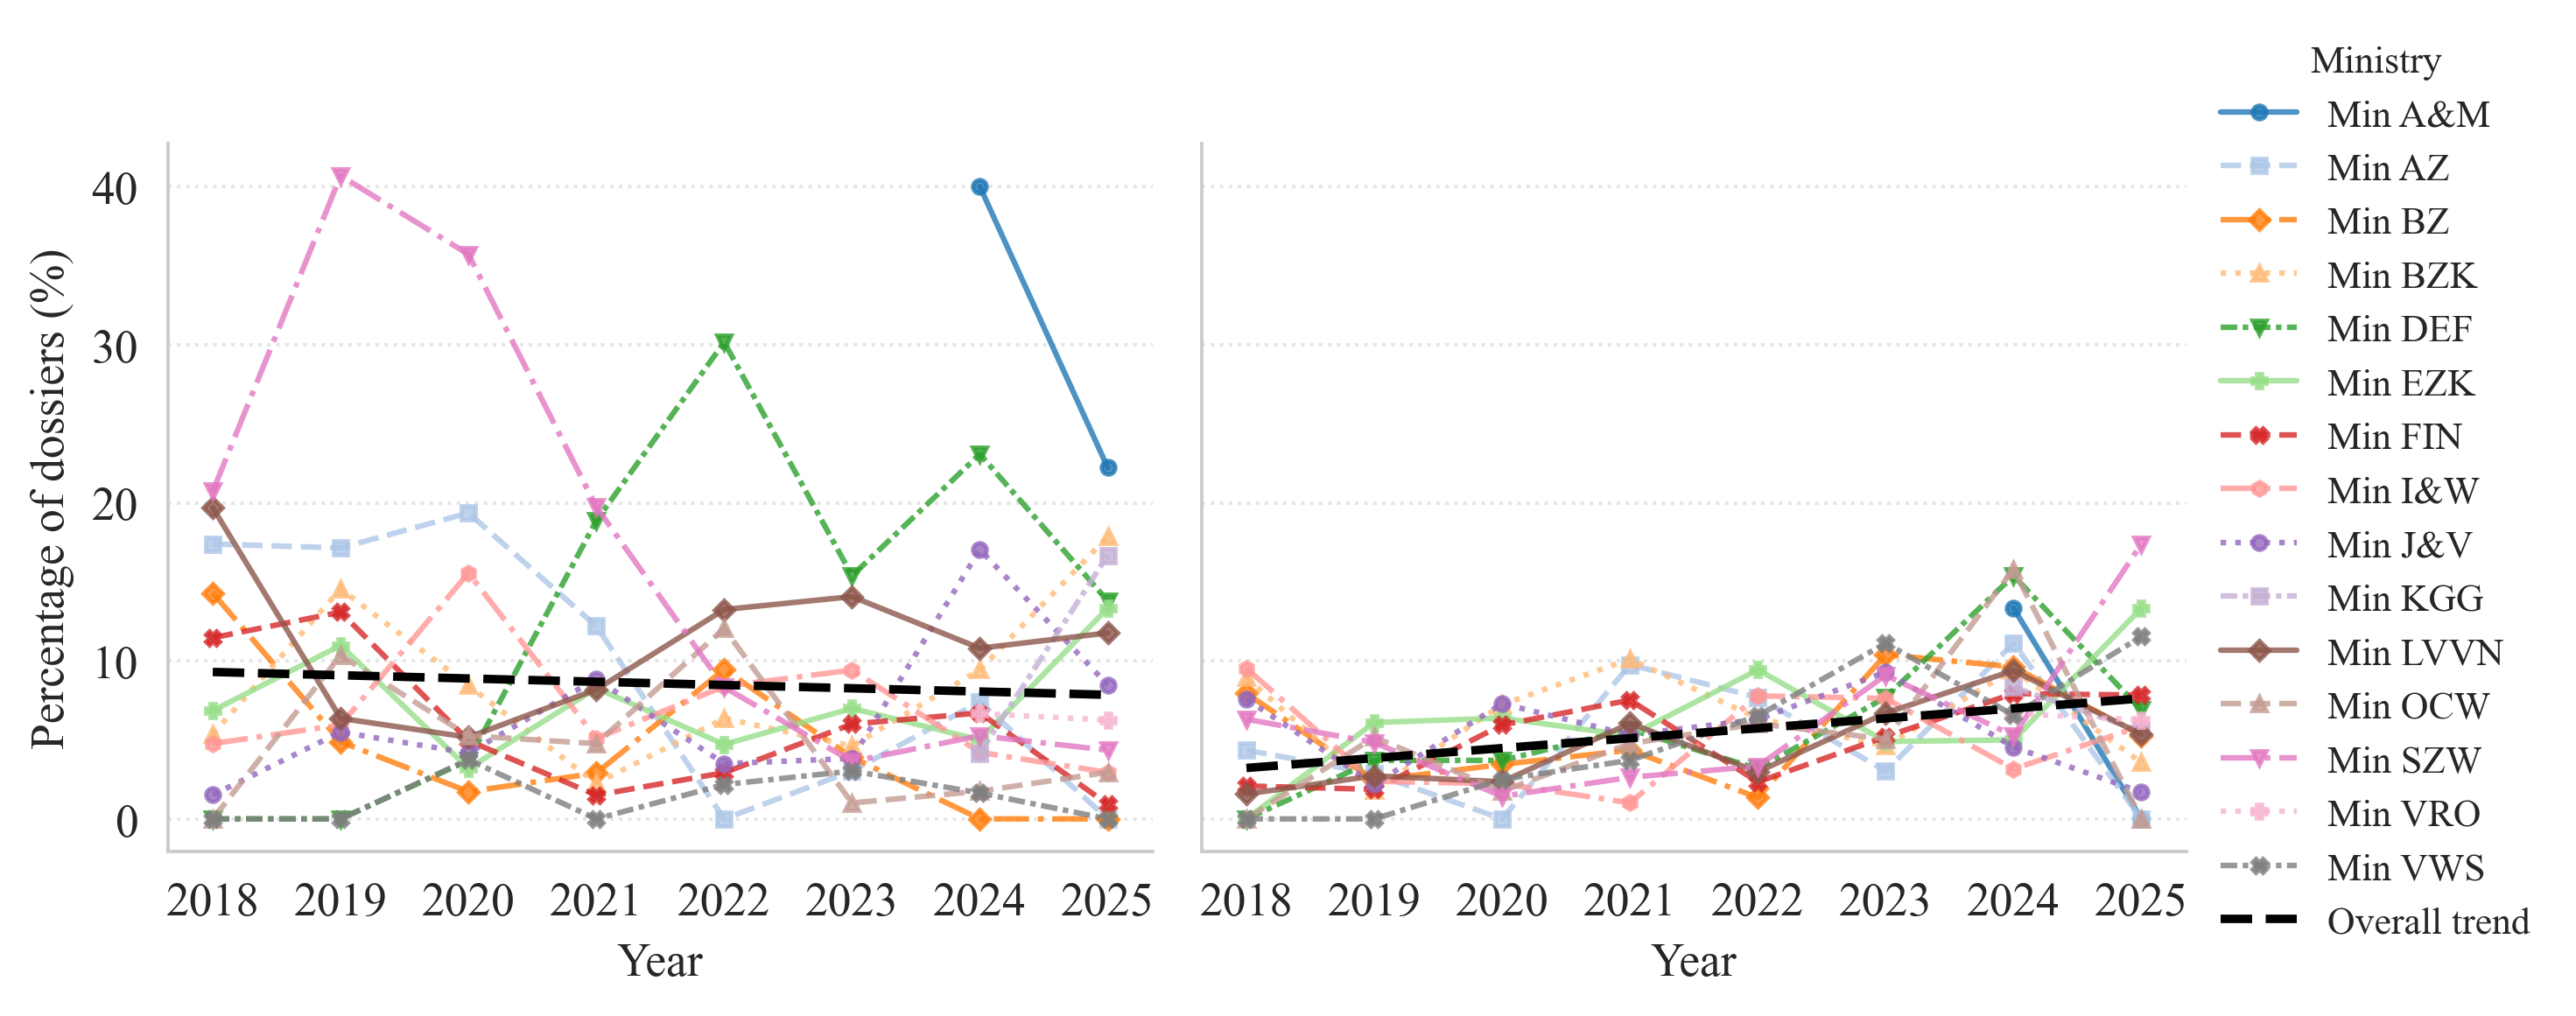

In [246]:
# ======== FIGURE WITH TWO PANELS ========
fig, axes = plt.subplots(
    1, 2,
    figsize=(8.5, 3.0),          # smaller, more compact figure
    sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.05} # panels closer together
)
ax_small, ax_large = axes

# Set font sizes for all plot elements
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['legend.title_fontsize'] = 9

colors = plt.cm.tab20.colors
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v", "P", "X", "h"]

ministry_handles = []   # to collect line objects
ministry_labels = []    # to collect ministry names

# ---- LEFT: % unusually small (local) ----
for i, ministry in enumerate(ministries):
    data = (
        percentages_local[
            percentages_local['dc_publisher_name'] == ministry
        ]
        .sort_values('year')
    )

    line = ax_small.plot(
        data['year'], data['pct_small_local'],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.3,
        markersize=3.2,
        alpha=0.8,
        label=ministry
    )[0]

    ministry_handles.append(line)
    ministry_labels.append(ministry)

ax_small.set_xlabel("Year")
ax_small.set_ylabel("Percentage of dossiers (%)")
ax_small.set_xticks(years_sorted)

# horizontal grid lines only, clearer
ax_small.yaxis.grid(True, linestyle=':', linewidth=0.8, alpha=0.5)
ax_small.xaxis.grid(False)

# ---- RIGHT: % unusually large (local) ----
for i, ministry in enumerate(ministries):
    data = (
        percentages_local[
            percentages_local['dc_publisher_name'] == ministry
        ]
        .sort_values('year')
    )

    ax_large.plot(
        data['year'], data['pct_large_local'],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.3,
        markersize=3.2,
        alpha=0.8
    )

ax_large.set_xlabel("Year")
ax_large.set_xticks(years_sorted)
ax_large.yaxis.grid(True, linestyle=':', linewidth=0.8, alpha=0.5)
ax_large.xaxis.grid(False)


# ======== OVERALL TRENDLINES (ACROSS MINISTRIES) ========

trend_small_line = None
trend_large_line = None

# --- Small ---
overall_small = (
    percentages_local
    .groupby("year", as_index=False)['pct_small_local']
    .mean()
    .sort_values("year")
)
x_s = overall_small['year'].to_numpy(dtype=float)
y_s = overall_small['pct_small_local'].to_numpy(dtype=float)

if x_s.size >= 2:
    slope_s, intercept_s = np.polyfit(x_s, y_s, 1)
    trend_s = slope_s * x_s + intercept_s
    trend_small_line = ax_small.plot(
        x_s, trend_s,
        color='black',
        linewidth=2.0,
        linestyle='--',
        label="Overall trend"
    )[0]

# --- Large ---
overall_large = (
    percentages_local
    .groupby("year", as_index=False)['pct_large_local']
    .mean()
    .sort_values("year")
)
x_l = overall_large['year'].to_numpy(dtype=float)
y_l = overall_large['pct_large_local'].to_numpy(dtype=float)

if x_l.size >= 2:
    slope_l, intercept_l = np.polyfit(x_l, y_l, 1)
    trend_l = slope_l * x_l + intercept_l
    trend_large_line = ax_large.plot(
        x_l, trend_l,
        color='black',
        linewidth=2.0,
        linestyle='--',
        label="_nolegend_"
    )[0]


# ======== BIG UNIFIED LEGEND (ministries + ONE trend entry) ========

from matplotlib.lines import Line2D

trend_proxy = Line2D([], [], color='black', linewidth=2.0, linestyle='--')

all_handles = ministry_handles + [trend_proxy]
all_labels  = ministry_labels + ["Overall trend"]

fig.legend(
    all_handles,
    all_labels,
    loc='center left',
    bbox_to_anchor=(0.9, 0.5),    # legend just to the right
    ncol=1,
    frameon=False,
    title="Ministry",
    title_fontsize=9,
    fontsize=9
)

# tighten figure; leaving room for legend on the right
fig.tight_layout(rect=(0, 0, 0.86, 1))

plt.savefig("big_small_dossiers.png", dpi=300)
plt.show()


##### Global values


In [123]:
import pandas as pd
import numpy as np

# ---------------------------------------------------
# 1. Dossier sizes per ministry / dossier / year
# ---------------------------------------------------
dossier_sizes_global = (
    complete_dataframe
    .groupby(['dc_publisher_name', 'foi_dossierId', 'dc_date_year'])['foi_pageNumber']
    .count()
    .reset_index()
)

dossier_sizes_global.columns = ['dc_publisher_name', 'foi_dossierId', 'year', 'num_pages']

# ---------------------------------------------------
# 2. Translate ministry names to short labels & keep ministries only
# ---------------------------------------------------
dossier_sizes_global['dc_publisher_name'] = (
    dossier_sizes_global['dc_publisher_name']
    .map(translation_dict)
    .fillna(dossier_sizes_global['dc_publisher_name'])
)

valid_ministries = list(translation_dict.values())
dossier_sizes_global = dossier_sizes_global[
    dossier_sizes_global['dc_publisher_name'].isin(valid_ministries)
]

# ---------------------------------------------------
# 3. GLOBAL 5th / 95th percentiles across all ministries
# ---------------------------------------------------
global_p5 = dossier_sizes_global['num_pages'].quantile(0.05)
global_p95 = dossier_sizes_global['num_pages'].quantile(0.95)

# Flags: small / large relative to GLOBAL thresholds
dossier_sizes_global['is_small_global'] = dossier_sizes_global['num_pages'] <= global_p5
dossier_sizes_global['is_large_global'] = dossier_sizes_global['num_pages'] >= global_p95

# ---------------------------------------------------
# 4. Aggregate: percentage small / large per ministry per year
# ---------------------------------------------------
percentages_global = (
    dossier_sizes_global
    .groupby(['dc_publisher_name', 'year'])
    .apply(lambda x: pd.Series({
        'pct_small_global': x['is_small_global'].mean() * 100,
        'pct_large_global': x['is_large_global'].mean() * 100,
    }))
    .reset_index()
)

# Keep years >= 2018 to match your other figures
percentages_global = percentages_global[percentages_global['year'] >= 2018]

# ---------------------------------------------------
# 5. Helper variables for plotting
# ---------------------------------------------------
ministries_global = sorted(percentages_global['dc_publisher_name'].unique())
years_sorted_global = sorted(percentages_global['year'].unique())


C:\Users\5677130\AppData\Local\Temp\ipykernel_35540\1946373108.py:149: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



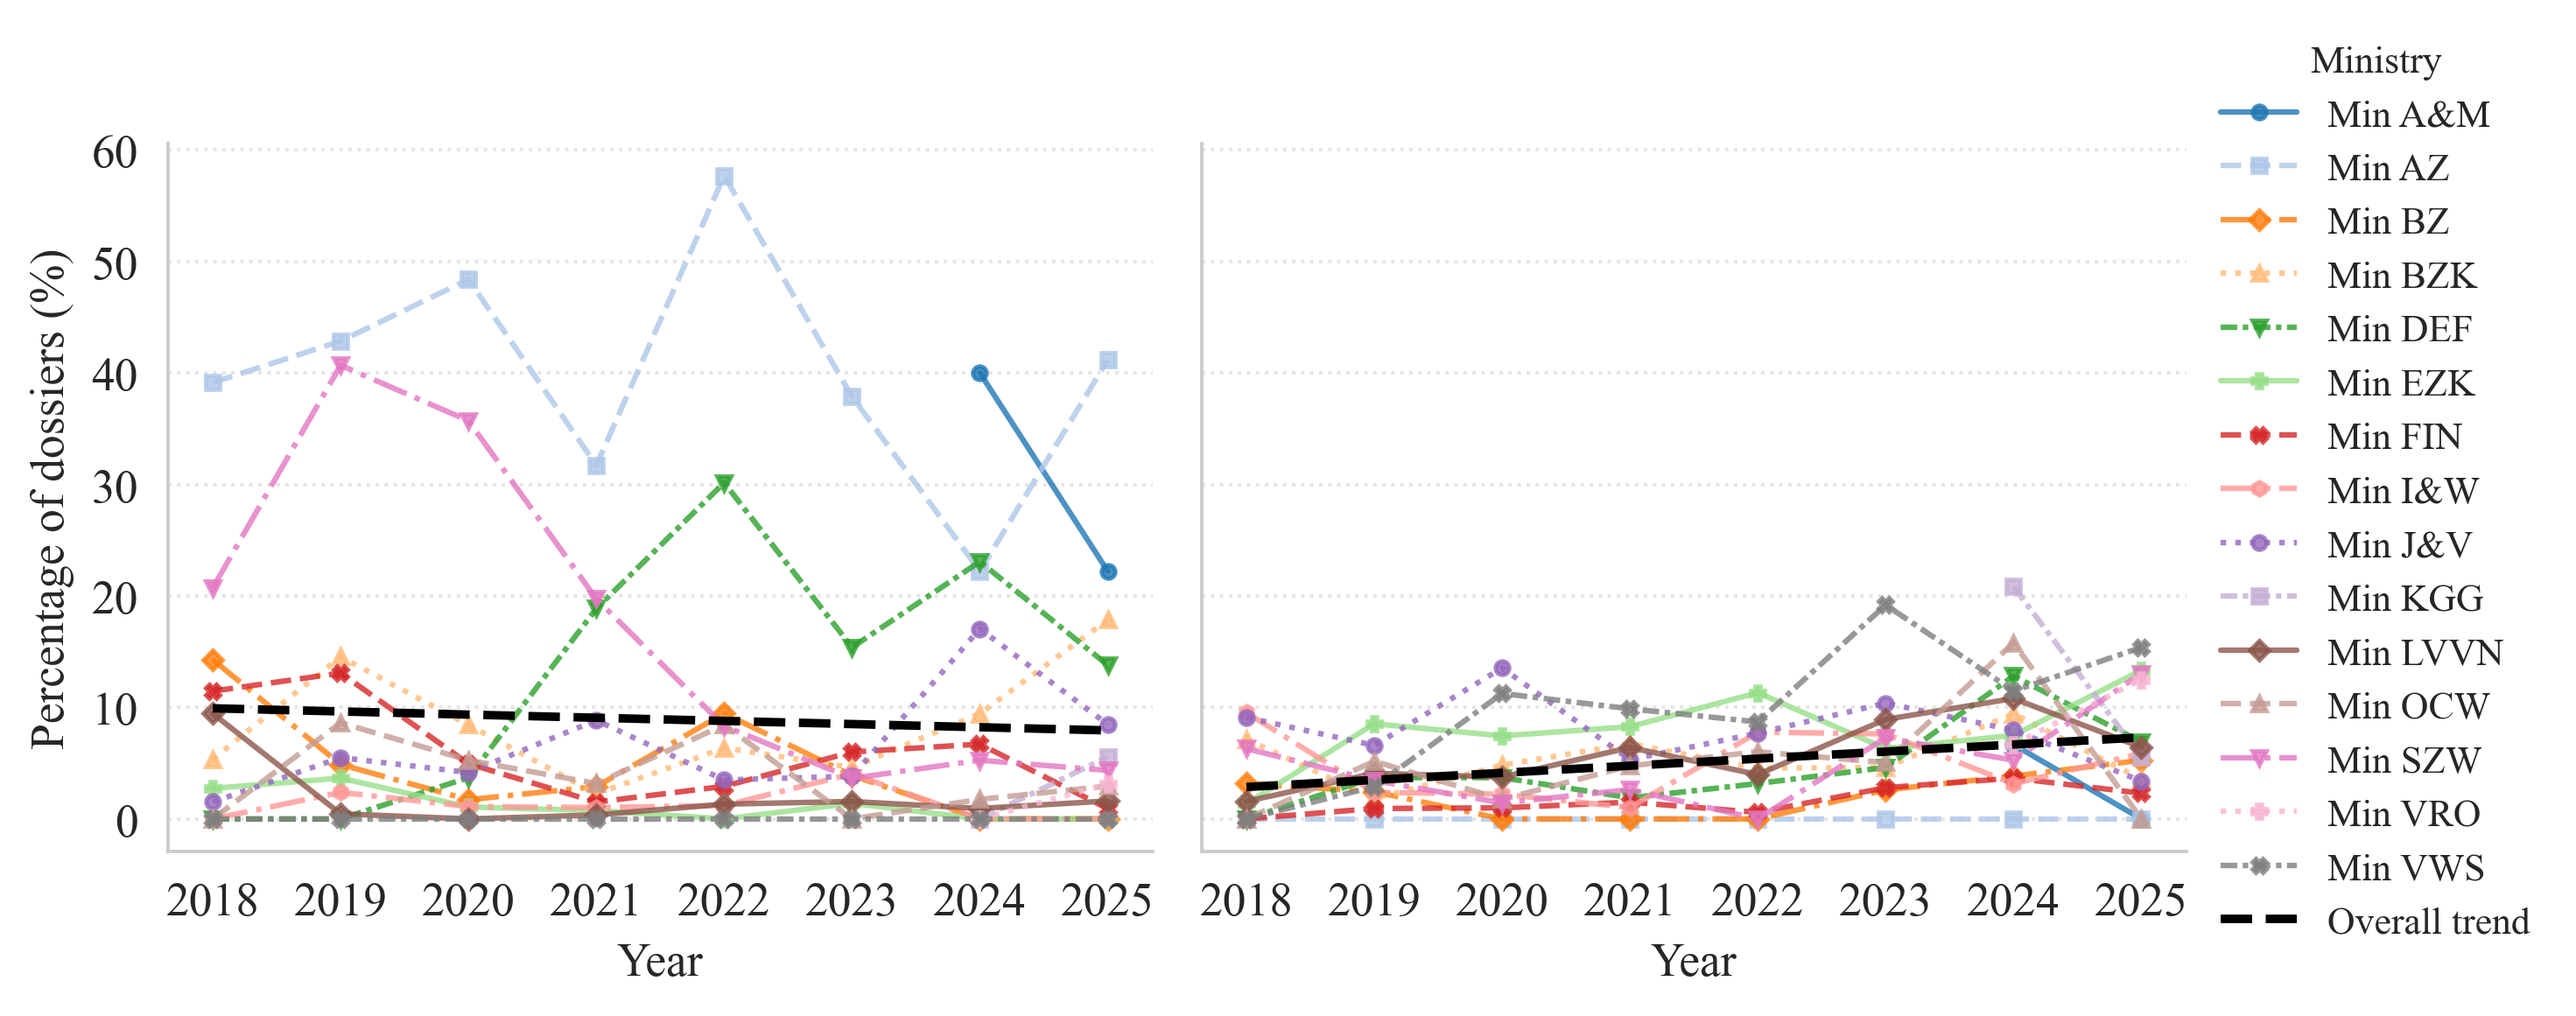

In [247]:
# ======== FIGURE WITH TWO PANELS (COMPACT GLOBAL) ========
fig, axes = plt.subplots(
    1, 2,
    figsize=(8.5, 3.0),          # match local figure size if you like
    sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.05} # panels closer together, like first
)
ax_small_g, ax_large_g = axes

# Set font sizes for all plot elements (as in first figure)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['legend.title_fontsize'] = 9

colors = plt.cm.tab20.colors
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v", "P", "X", "h"]

ministry_handles_g = []
ministry_labels_g = []

# ---- LEFT PANEL: unusually small (GLOBAL) ----
for i, ministry in enumerate(ministries_global):
    data = (
        percentages_global[
            percentages_global['dc_publisher_name'] == ministry
        ]
        .sort_values('year')
    )

    line = ax_small_g.plot(
        data['year'], data['pct_small_global'],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.3,
        markersize=3.2,
        alpha=0.8,
        label=ministry
    )[0]

    ministry_handles_g.append(line)
    ministry_labels_g.append(ministry)

# no panel title (to mirror first figure)
ax_small_g.set_xlabel("Year")
ax_small_g.set_ylabel("Percentage of dossiers (%)")
ax_small_g.set_xticks(years_sorted_global)

# Horizontal gridlines only
ax_small_g.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.5)
ax_small_g.xaxis.grid(False)

# ---- RIGHT PANEL: unusually large (GLOBAL) ----
for i, ministry in enumerate(ministries_global):
    data = (
        percentages_global[
            percentages_global['dc_publisher_name'] == ministry
        ]
        .sort_values('year')
    )

    ax_large_g.plot(
        data['year'], data['pct_large_global'],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.3,
        markersize=3.2,
        alpha=0.8
    )

# no panel title
ax_large_g.set_xlabel("Year")
ax_large_g.set_xticks(years_sorted_global)

ax_large_g.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.5)
ax_large_g.xaxis.grid(False)

# ======== OVERALL TRENDLINES (GLOBAL) ========

trend_small_line_g = None
trend_large_line_g = None

# ---- Small dossiers trend ----
overall_small_g = (
    percentages_global
    .groupby("year", as_index=False)['pct_small_global']
    .mean()
    .sort_values("year")
)
x_sg = overall_small_g['year'].to_numpy(dtype=float)
y_sg = overall_small_g['pct_small_global'].to_numpy(dtype=float)

if x_sg.size >= 2:
    slope_sg, intercept_sg = np.polyfit(x_sg, y_sg, 1)
    trend_small_line_g = ax_small_g.plot(
        x_sg, slope_sg * x_sg + intercept_sg,
        color="black",
        linewidth=2.0,
        linestyle="--",
        label="_nolegend_"   # no legend entry here
    )[0]

# ---- Large dossiers trend ----
overall_large_g = (
    percentages_global
    .groupby("year", as_index=False)['pct_large_global']
    .mean()
    .sort_values("year")
)
x_lg = overall_large_g['year'].to_numpy(dtype=float)
y_lg = overall_large_g['pct_large_global'].to_numpy(dtype=float)

if x_lg.size >= 2:
    slope_lg, intercept_lg = np.polyfit(x_lg, y_lg, 1)
    trend_large_line_g = ax_large_g.plot(
        x_lg, slope_lg * x_lg + intercept_lg,
        color="black",
        linewidth=2.0,
        linestyle="--",
        label="_nolegend_"   # no legend entry here either
    )[0]

# ======== BIG UNIFIED LEGEND (ministries + ONE trend entry) ========
from matplotlib.lines import Line2D

trend_proxy_g = Line2D([], [], color='black', linewidth=2.0, linestyle='--')

all_handles_g = ministry_handles_g + [trend_proxy_g]
all_labels_g  = ministry_labels_g + ["Overall trend"]

fig.legend(
    all_handles_g,
    all_labels_g,
    loc='center left',
    bbox_to_anchor=(0.9, 0.5),    # legend to the right, like first fig
    ncol=1,
    frameon=False,
    title="Ministry",
    title_fontsize=9,
    fontsize=9
)

# tighten figure; leave room for legend on the right
fig.tight_layout(rect=(0, 0, 0.86, 1))

plt.savefig("big_small_dossiers_global.png", dpi=300)
plt.show()


In [248]:
print(f"Global 5th percentile threshold (small dossiers): ≤ {global_p5:.2f} pages")
print(f"Global 95th percentile threshold (large dossiers): ≥ {global_p95:.2f} pages")


Global 5th percentile threshold (small dossiers): ≤ 2.00 pages
Global 95th percentile threshold (large dossiers): ≥ 636.35 pages


#### Obstructive Formatting

In [14]:
# We have multiple iterations of the score, v2 is the latest so we select this
complete_dataframe['foi_fairiscore'] = complete_dataframe['foi_fairiscoreVersions'].apply(lambda item: eval(item) if (isinstance(item, str) and not 'null' in item) else pd.NA).str['v2']
dossier_and_document_dataframe['foi_fairiscore'] = dossier_and_document_dataframe['foi_fairiscoreVersions'].apply(lambda item: eval(item) if (isinstance(item, str) and not 'null' in item) else pd.NA).str['v2']

In [17]:
color_dict = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}
fair_ministries_df = dossier_and_document_dataframe[dossier_and_document_dataframe.dc_publisher.str.startswith('mnre')]
fair_ministries_df = fair_ministries_df[~fair_ministries_df.foi_fairiscore.isna()]
fair_ministries_df['foi_fairiscore'] = fair_ministries_df['foi_fairiscore'].apply(lambda x: color_dict[x])
fair_ministries_df['dc_publisher_name'] =  fair_ministries_df['dc_publisher_name'].apply(lambda x: translation_dict[x])
fair_ministries_df = fair_ministries_df.sort_values(by='dc_publisher_name')

In [ ]:
from scipy.stats import linregress

import plotly.graph_objects as go

# Create a mapping for the score values (5 is highest)
score_mapping = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'E': 1}

# Prepare data: filter for ministries and add year column
ministry_yearly_scores = fair_ministries_df.copy()
ministry_yearly_scores['year'] = ministry_yearly_scores['dc_date_year'].astype(float)

# Drop rows without year
ministry_yearly_scores = ministry_yearly_scores.dropna(subset=['year'])

# Filter for years >= 2018
ministry_yearly_scores = ministry_yearly_scores[ministry_yearly_scores['year'] >= 2018]

# Convert FAIRIscore to numeric
ministry_yearly_scores['score_numeric'] = ministry_yearly_scores['foi_fairiscore'].map(score_mapping)

# Calculate average score and count per ministry per year
yearly_stats = ministry_yearly_scores.groupby(['dc_publisher_name', 'year'])['score_numeric'].agg(['mean', 'count']).reset_index()

# Create the interactive plot
fig = go.Figure()

# Plot a line for each ministry
for ministry in yearly_stats['dc_publisher_name'].unique():
    ministry_data = yearly_stats[yearly_stats['dc_publisher_name'] == ministry]
    
    # Create hover text with count information
    hover_text = [f"Year: {int(year)}<br>Avg Score: {score:.2f}<br>Documents: {count}" 
                  for year, score, count in zip(ministry_data['year'], 
                                                 ministry_data['mean'], 
                                                 ministry_data['count'])]
    
    fig.add_trace(go.Scatter(
        x=ministry_data['year'],
        y=ministry_data['mean'],
        mode='lines+markers',
        name=ministry,
        hovertext=hover_text,
        hoverinfo='text',
        line=dict(width=2),
        marker=dict(size=6)
    ))

# Add overall trendline
overall_stats = yearly_stats.groupby('year')['mean'].mean().reset_index()
slope, intercept, r_value, p_value, std_err = linregress(overall_stats['year'], overall_stats['mean'])
trendline_y = slope * overall_stats['year'] + intercept

fig.add_trace(go.Scatter(
    x=overall_stats['year'],
    y=trendline_y,
    mode='lines',
    name='Overall Trend',
    line=dict(color='black', width=3, dash='dash'),
    hovertemplate='Trendline<br>Year: %{x}<br>Score: %{y:.2f}<extra></extra>'
))

fig.update_layout(
    title='Average FAIRIscore per Ministry Over Time (2018-2025)',
    xaxis_title='Year Published',
    yaxis_title='Average FAIRIscore',
    yaxis=dict(
        range=[0.5, 5.5],
        tickmode='array',
        tickvals=[1, 2, 3, 4, 5],
        ticktext=['E', 'D', 'C', 'B', 'A']
    ),
    hovermode='closest',
    height=600,
    width=1000,
    legend=dict(font=dict(size=9))
)

fig.show()

In [16]:
# ========= GLOBAL STYLE FOR PAPER =========
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "CMU Serif"],
    "figure.dpi": 350,
    "savefig.dpi": 350,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

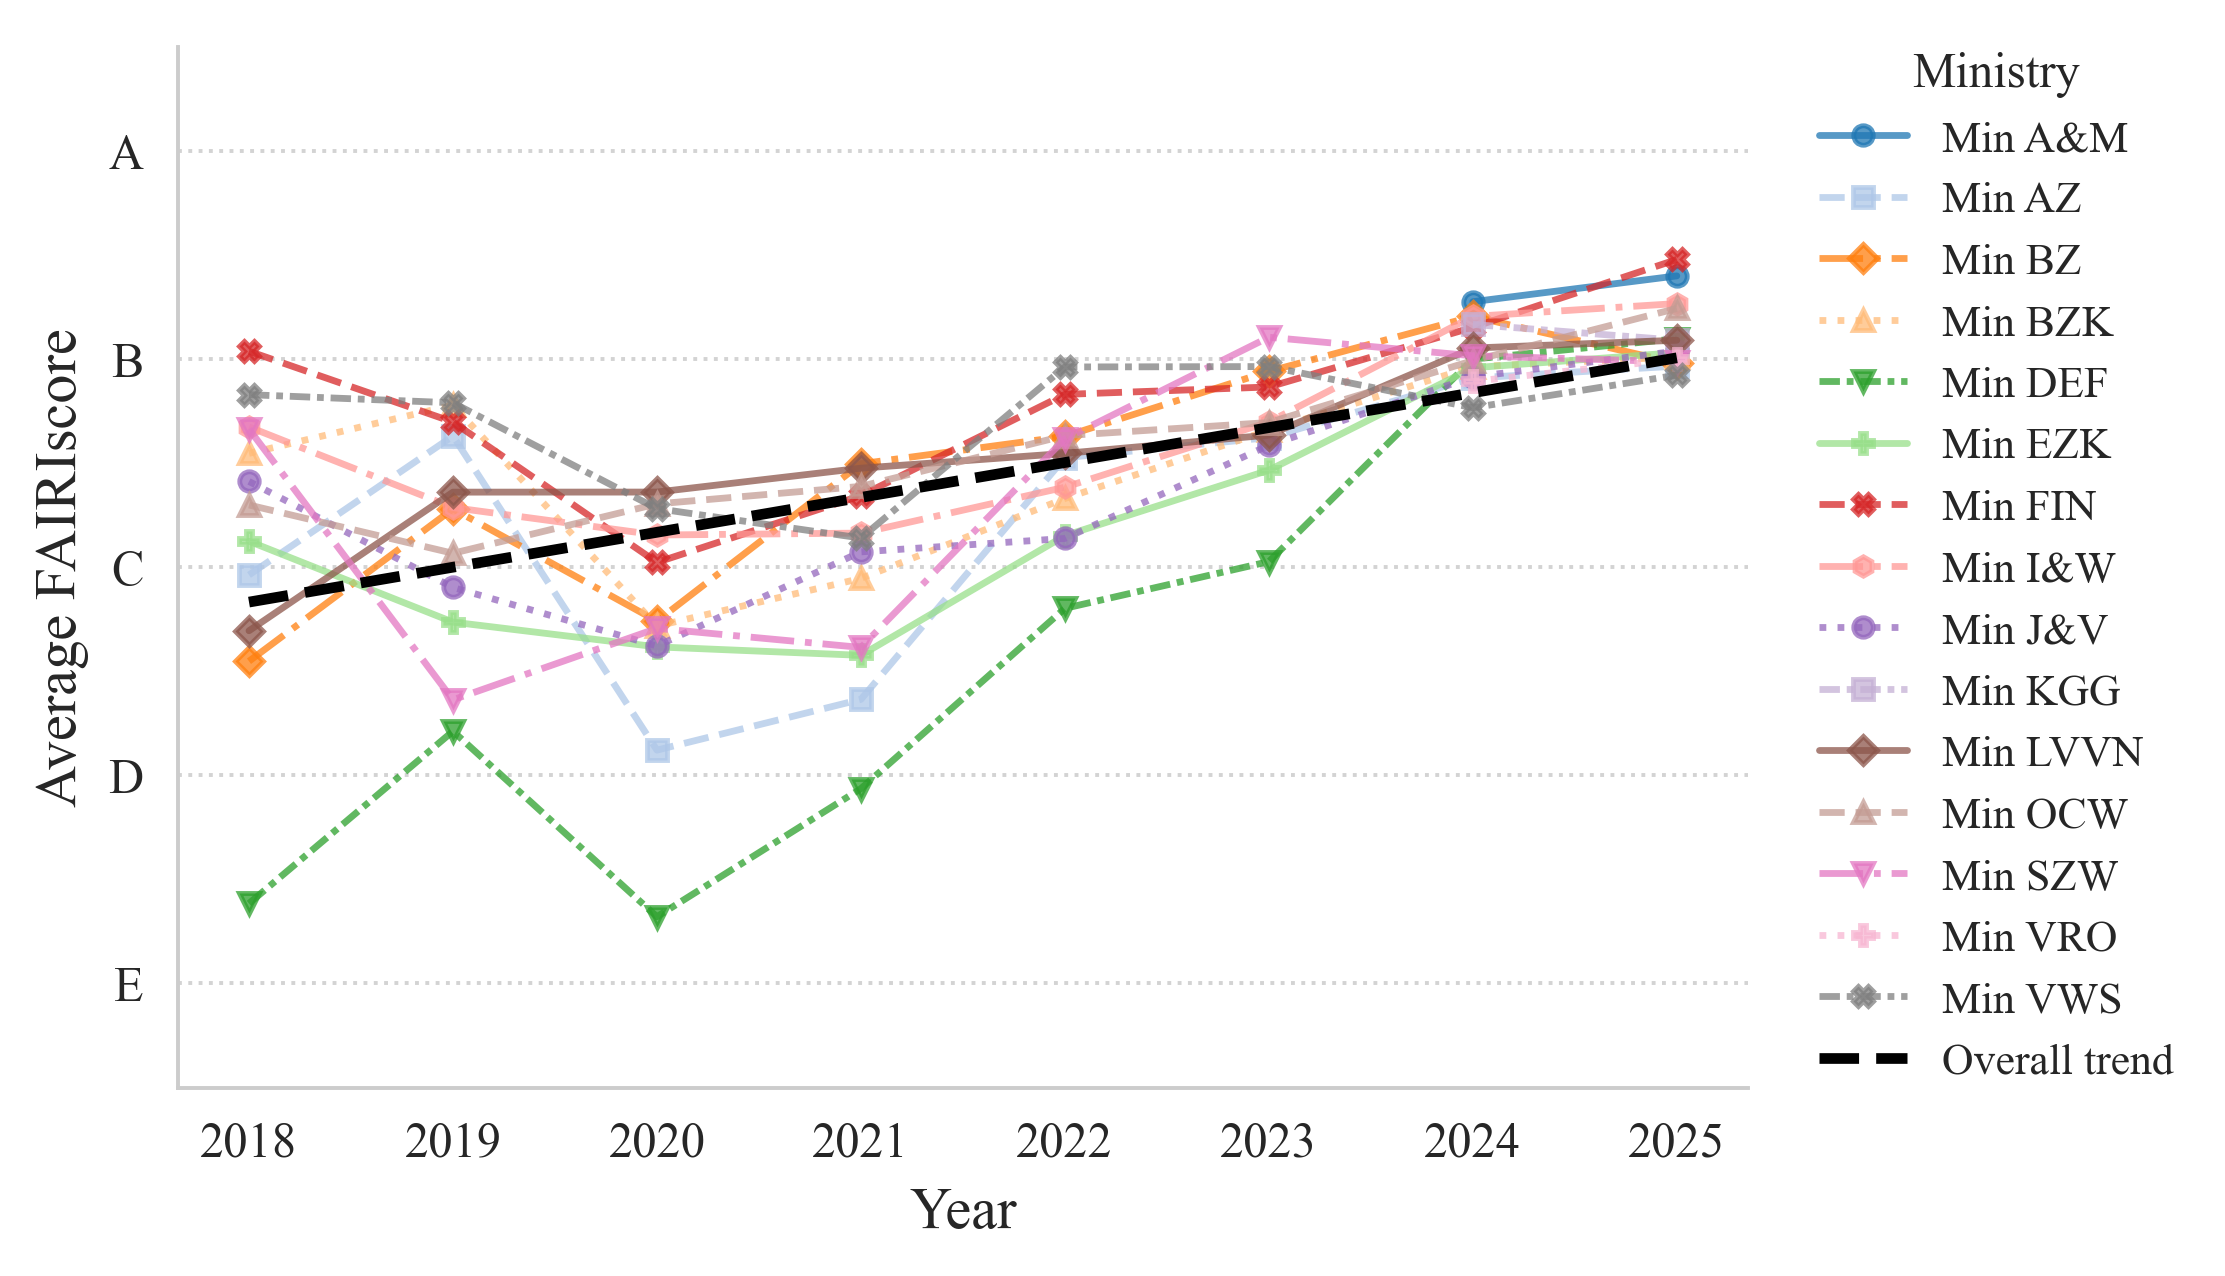

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))

ministries = sorted(yearly_stats["dc_publisher_name"].unique())

# Use a muted qualitative palette to reduce clutter
colors = plt.cm.tab20.colors
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v", "P", "X", "h"]

for i, ministry in enumerate(ministries):
    data = yearly_stats[yearly_stats["dc_publisher_name"] == ministry].sort_values("year")
    ax.plot(
        data["year"],
        data["mean"],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.4,
        markersize=4,
        alpha=0.75,
        label=ministry,
    )

# ========== OVERALL TRENDLINE ==========
overall_stats = yearly_stats.groupby("year", as_index=False)["mean"].mean()
slope, intercept, *_ = linregress(overall_stats["year"], overall_stats["mean"])
trendline = slope * overall_stats["year"] + intercept

ax.plot(
    overall_stats["year"],
    trendline,
    color="black",
    linewidth=2.2,
    linestyle="--",
    label="Overall trend",
)

# ========== AXES & GRID ==========
ax.set_xlabel("Year")
ax.set_ylabel("Average FAIRIscore")

ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["E", "D", "C", "B", "A"])

ax.yaxis.grid(True, linestyle=":", alpha=0.85)
ax.xaxis.grid(False)

# ========== LEGEND ==========
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Ministry",
    title_fontsize=10,
)

fig.tight_layout()
fig.savefig("fairscores_ministry_over_time.png", bbox_inches='tight')
plt.show()

### Excessive Redaction

In [42]:
redacted = complete_dataframe.foi_redacted
print(f"There is a total of {int(redacted.sum()):,d} pages that have at least one redaction, rouhgly {redacted.mean():,.2f} percent of the data")

There is a total of 523,603 pages that have at least one redaction, rouhgly 0.45 percent of the data


In [43]:
pages_with_redactions = complete_dataframe[complete_dataframe.foi_redacted]

In [44]:
pages_with_redactions = pages_with_redactions[~pages_with_redactions.foi_nrRedactedRegions.isna()]

In [45]:
print(f"There is a total of {int(pages_with_redactions.foi_nrRedactedRegions.sum()):,d} redactions in the dataset, with an average of {pages_with_redactions.foi_nrRedactedRegions.mean():,.2f} per page")

There is a total of 4,359,857 redactions in the dataset, with an average of 8.33 per page


Now we calculate the average redaction rates per ministry.

In [ ]:
# Calculate average percentage of text area redacted per ministry per year
text_area_redacted_by_ministry_year = complete_dataframe.groupby(['dc_publisher_name', 'dc_date_year']).agg({
    'foi_percentageTextAreaRedacted': 'mean'
}).reset_index()

# Rename columns for clarity
text_area_redacted_by_ministry_year.columns = ['dc_publisher_name', 'dc_date_year', 'avg_pct_text_area_redacted']

# Apply translation to ministry names
text_area_redacted_by_ministry_year['dc_publisher_name'] = text_area_redacted_by_ministry_year['dc_publisher_name'].map(translation_dict).fillna(text_area_redacted_by_ministry_year['dc_publisher_name'])

# Filter for ministries only
ministry_names = list(translation_dict.values())
text_area_redacted_by_ministry_year = text_area_redacted_by_ministry_year[text_area_redacted_by_ministry_year['dc_publisher_name'].isin(ministry_names)]

# Filter for years >= 2018
text_area_redacted_by_ministry_year = text_area_redacted_by_ministry_year[text_area_redacted_by_ministry_year['dc_date_year'] >= 2018]

# Sort by ministry and year
text_area_redacted_by_ministry_year.sort_values(['dc_publisher_name', 'dc_date_year'])




,112,113,114,115,116,117,118,119,129,130,...,286,287,288,289,290,291,292,293,294,295
dc_publisher_name,Min AZ,Min AZ,Min AZ,Min AZ,Min AZ,Min AZ,Min AZ,Min AZ,Min BZK,Min BZK,...,Min LVVN,Min LVVN,Min LVVN,Min LVVN,Min LVVN,Min LVVN,Min LVVN,Min LVVN,Min VRO,Min VRO
dc_date_year,2018,2019,2020,2021,2022,2023,2024,2025,2018,2019,...,2018,2019,2020,2021,2022,2023,2024,2025,2024,2025
avg_pct_text_area_redacted,NaN,NaN,2.41355,3.809732,1.869143,3.264491,NaN,NaN,NaN,NaN,...,1.373253,1.300595,7.706876,4.554054,4.545596,5.324814,NaN,NaN,NaN,NaN


In [79]:
# Calculate number of pages per ministry per year
redaction_by_ministry_year = complete_dataframe.groupby(['dc_publisher_name', 'dc_date_year']).agg({
    'foi_redacted': lambda x: (x == True).sum() / len(x) * 100,  # percentage of pages with redactions
    'foi_percentageTextAreaRedacted': 'mean',  # average percentage of text area redacted,
    'foi_percentageCharAreaRedacted': 'mean',
    'foi_nrRedactedRegions' : 'mean'
}).reset_index()

# Rename columns for clarity
redaction_by_ministry_year.columns = ['dc_publisher_name', 'dc_date_year', 'pct_pages_redacted', 'avg_pct_text_area_redacted', 'avg_pct_char_area_redacted', 'avg_nr_redacted_regions']
# Apply translation to ministry names
redaction_by_ministry_year['dc_publisher_name'] = redaction_by_ministry_year['dc_publisher_name'].map(translation_dict).fillna(redaction_by_ministry_year['dc_publisher_name'])

# Filter for ministries only
redaction_by_ministry_year = redaction_by_ministry_year[redaction_by_ministry_year['dc_publisher_name'].isin(ministry_names)]

# Sort by ministry and year
redaction_by_ministry_year = redaction_by_ministry_year.sort_values(['dc_publisher_name', 'dc_date_year'])

redaction_by_ministry_year

,dc_publisher_name,dc_date_year,pct_pages_redacted,avg_pct_text_area_redacted,avg_pct_char_area_redacted,avg_nr_redacted_regions
260,Min A&M,2024,0.000000,NaN,NaN,<NA>
261,Min A&M,2025,0.000000,NaN,NaN,<NA>
104,Min AZ,2010,0.000000,NaN,NaN,<NA>
105,Min AZ,2011,0.000000,NaN,NaN,<NA>
106,Min AZ,2012,0.000000,NaN,NaN,<NA>
...,...,...,...,...,...,...
255,Min VWS,2021,60.170507,7.418816,20.134040,6.421103
256,Min VWS,2022,6.208486,6.440097,17.934172,5.446051
257,Min VWS,2023,5.968902,8.477862,19.665362,6.370097
258,Min VWS,2024,0.000000,NaN,NaN,<NA>


In [97]:
import plotly.graph_objects as go

# Filter for years >= 2018 to match other plots
redaction_by_ministry_year_filtered = redaction_by_ministry_year[redaction_by_ministry_year['dc_date_year'] >= 2018]

# Create the interactive plot
fig = go.Figure()

# Plot a line for each ministry
for ministry in sorted(redaction_by_ministry_year_filtered['dc_publisher_name'].unique()):
    ministry_data = redaction_by_ministry_year_filtered[
        redaction_by_ministry_year_filtered['dc_publisher_name'] == ministry
    ].sort_values('dc_date_year')
    
    # Create hover text with count information
    hover_text = [f"Year: {int(year)}<br>% Pages Redacted: {pct:.2f}%" 
                  for year, pct in zip(ministry_data['dc_date_year'], 
                                       ministry_data['avg_pct_text_area_redacted'])]
    
    fig.add_trace(go.Scatter(
        x=ministry_data['dc_date_year'],
        y=ministry_data['avg_pct_text_area_redacted'],
        mode='lines+markers',
        name=ministry,
        hovertext=hover_text,
        hoverinfo='text',
        line=dict(width=2),
        marker=dict(size=6)
    ))

fig.update_layout(
    title='Average Percentage of Text Area Redacted per Ministry Over Time (2018-2025)',
    xaxis_title='Year',
    yaxis_title='Average Percentage of Text Area Redacted (%)',
    hovermode='closest',
    height=600,
    width=800,
    legend=dict(font=dict(size=9))
)

fig.show()


<Figure size 2240x1680 with 0 Axes>

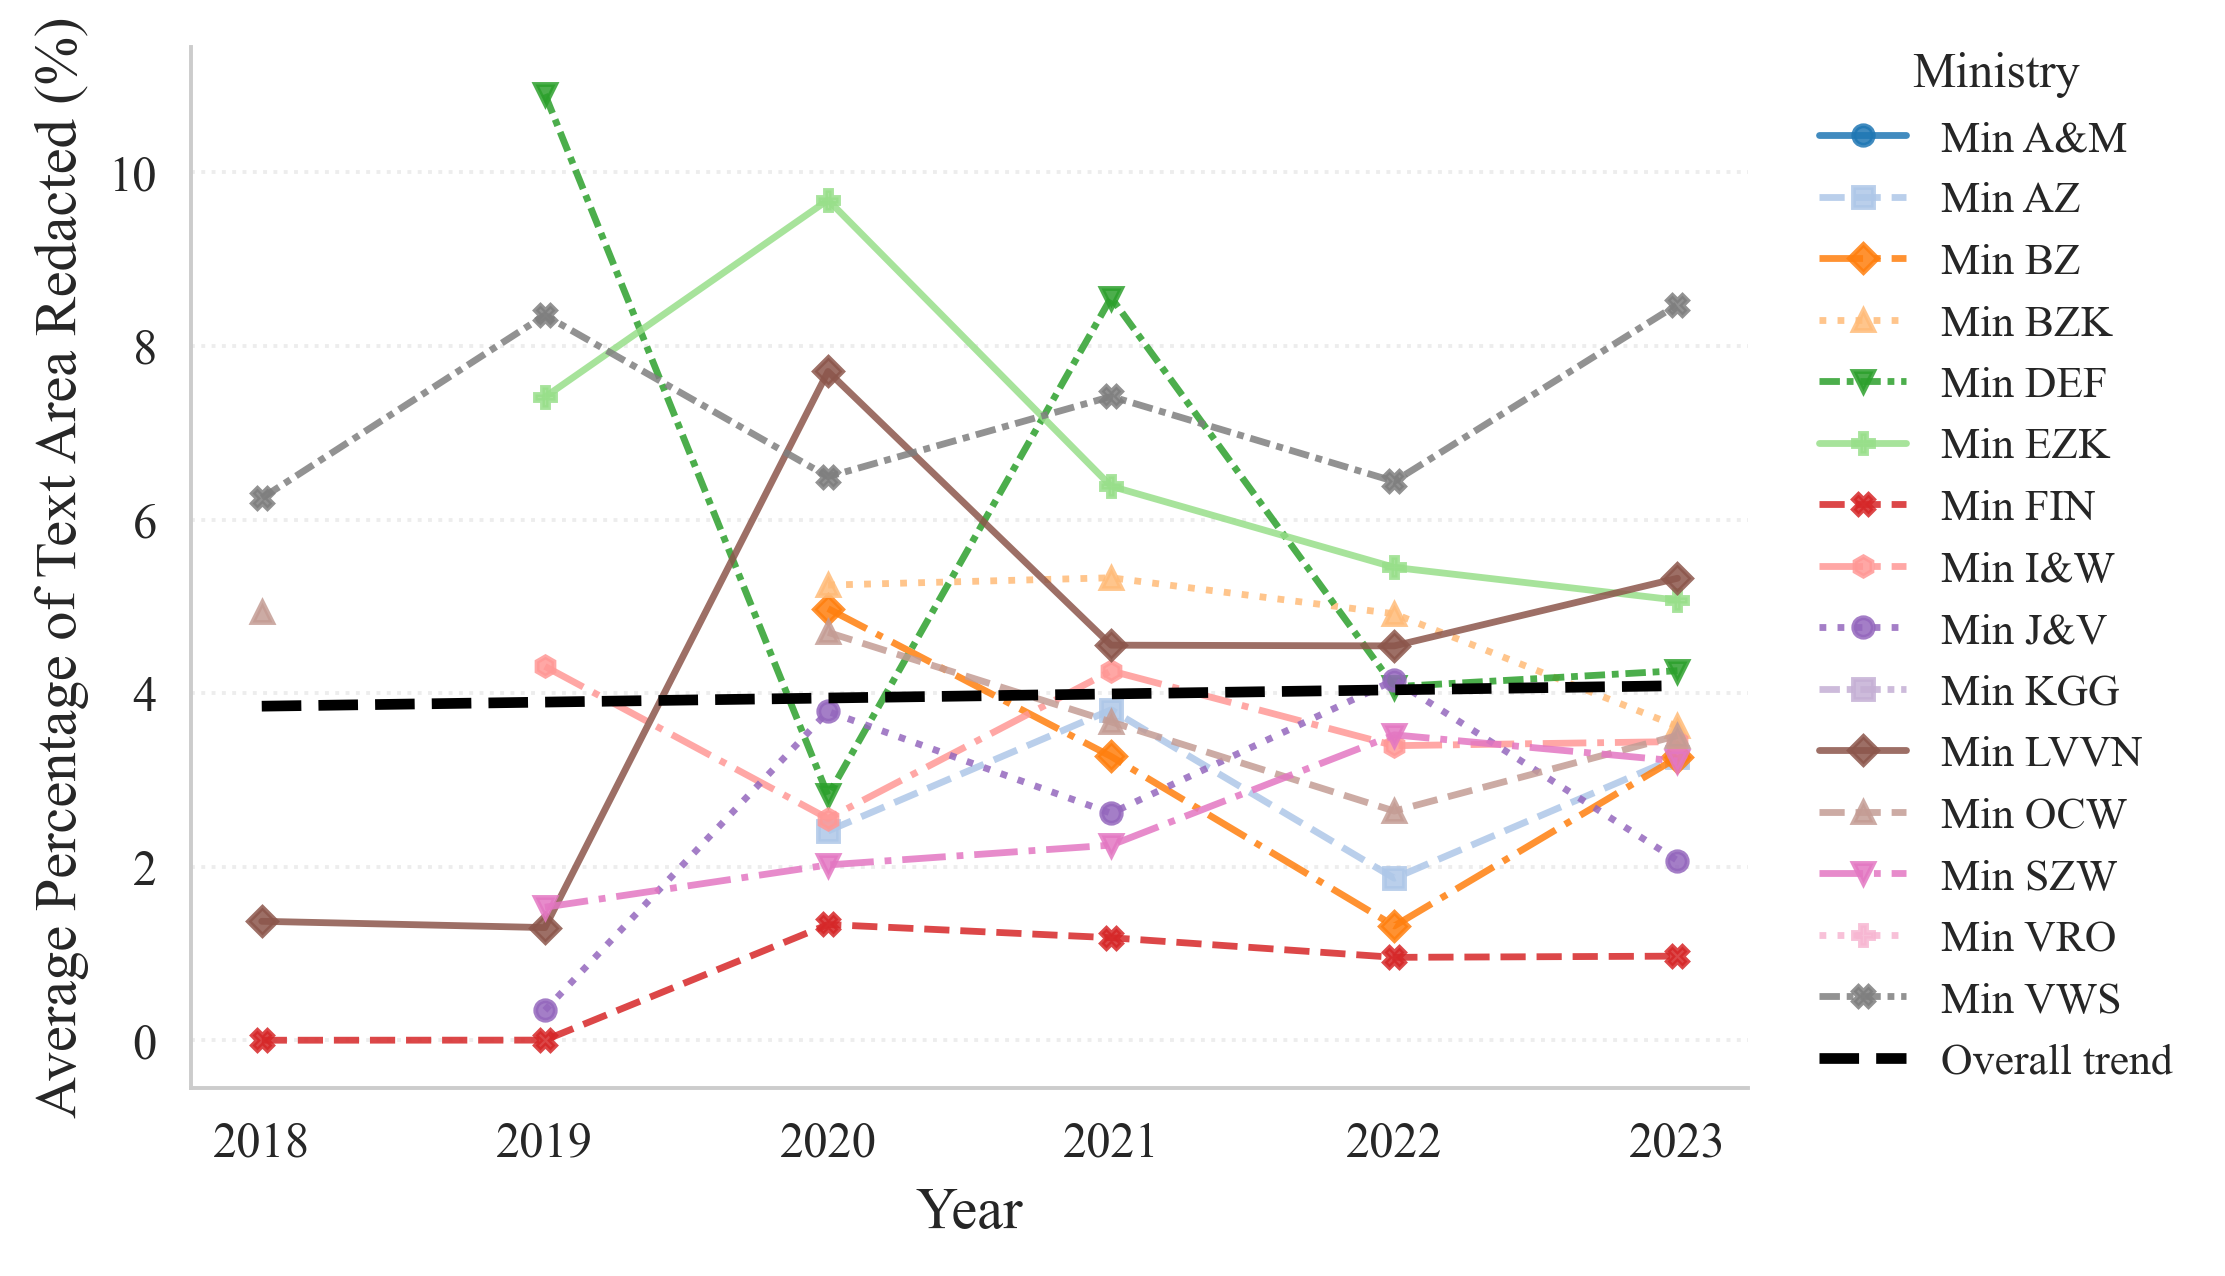

In [96]:
# ======== FILTER YEARS TO MATCH OTHER PLOTS ========
redaction_by_ministry_year_filtered = redaction_by_ministry_year[
    redaction_by_ministry_year["dc_date_year"] >= 2018
].copy()

fig, ax = plt.subplots(figsize=(6.5, 3.8))  # column-width figure

ministries = sorted(redaction_by_ministry_year_filtered["dc_publisher_name"].unique())

colors = plt.cm.tab20.colors
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v", "P", "X", "h"]

# ======== PLOT EACH MINISTRY ========
for i, ministry in enumerate(ministries):
    mdata = (
        redaction_by_ministry_year_filtered[
            redaction_by_ministry_year_filtered["dc_publisher_name"] == ministry
        ]
        .sort_values("dc_date_year")
    )

    ax.plot(
        mdata["dc_date_year"],
        mdata["avg_pct_text_area_redacted"],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.4,
        markersize=4,
        alpha=0.85,
        label=ministry,
    )

# ======== OVERALL YEARLY AVERAGE & TRENDLINE ========
overall = (
    redaction_by_ministry_year_filtered
    .groupby("dc_date_year", as_index=False)["avg_pct_text_area_redacted"]
    .mean()
    .sort_values("dc_date_year")
)

# Make sure we have clean numeric arrays
years = pd.to_numeric(overall["dc_date_year"], errors="coerce")
avg_redacted = pd.to_numeric(overall["avg_pct_text_area_redacted"], errors="coerce")

mask = years.notna() & avg_redacted.notna()

# Force float dtype so polyfit is happy
x = years[mask].astype(float).to_numpy()
y = avg_redacted[mask].astype(float).to_numpy()

if x.size >= 2:
    slope, intercept = np.polyfit(x, y, 1)
    trend_y = slope * x + intercept

    ax.plot(
        x,
        trend_y,
        color="black",
        linewidth=2.2,
        linestyle="--",
        label="Overall trend",
    )


# ======== LABELS & GRID ========
ax.set_xlabel("Year")
ax.set_ylabel("Average Percentage of Text Area Redacted (%)")

ax.yaxis.grid(True, linestyle=":", alpha=0.35)
ax.xaxis.grid(False)

# ======== LEGEND ========
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9,
    title="Ministry",
    title_fontsize=10,
)

fig.tight_layout()
plt.savefig("redaction_ministry_over_time.png", bbox_inches='tight')
plt.show()


### Catch-All Exemptions

First, we count all occurrences of certain exemptions. Note that these exemptions were introduced with the new Dutch FOIA in 2022.

| Code        | Type                            | Legal basis                                          | Brief description                                                                                                                                                               |
| ----------- | ------------------------------- | ---------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **5.1.1.a** | **Absolute**                    | Art. 5.1 para 1 sub a                                | The unity of the Crown could be endangered.                                                                                                                                     |
| **5.1.1.b** | **Absolute**                    | Art. 5.1 para 1 sub b                                | The security of the State could be harmed.                                                                                                                                      |
| **5.1.1.c** | **Absolute**                    | Art. 5.1 para 1 sub c                                | Business and manufacturing data provided confidentially to the government.                                                                                                       |
| **5.1.1.d** | **Absolute**                    | Art. 5.1 para 1 sub d                                | Personal data (GDPR/UAVG), unless the data subject gave consent or made it public themselves.                                                                                    |
| **5.1.1.e** | **Absolute**                    | Art. 5.1 para 1 sub e                                | Legally required identification numbers (such as BSN) unless disclosure does not infringe on privacy.                                                                            |
| **5.1.2.a** | **Relative**                    | Art. 5.1 para 2 sub a                                | The relations of the Netherlands with other states or international organizations.                                                                                               |
| **5.1.2.b** | **Relative**                    | Art. 5.1 para 2 sub b                                | The economic or financial interests of the State or other administrative bodies.                                                                                                 |
| **5.1.2.c** | **Relative**                    | Art. 5.1 para 2 sub c                                | The detection and prosecution of criminal offenses.                                                                                                                              |
| **5.1.2.d** | **Relative**                    | Art. 5.1 para 2 sub d                                | The inspection, control and supervision work of administrative bodies.                                                                                                           |
| **5.1.2.e** | **Relative**                    | Art. 5.1 para 2 sub e                                | Respect for personal privacy.                                                                                                                                                    |
| **5.1.2.f** | **Relative**                    | Art. 5.1 para 2 sub f                                | Other confidential or competition-sensitive business and manufacturing data.                                                                                                     |
| **5.1.2.g** | **Relative**                    | Art. 5.1 para 2 sub g                                | The protection of the environment to which the information relates.                                                                                                              |
| **5.1.2.h** | **Relative**                    | Art. 5.1 para 2 sub h                                | The safety of persons and companies and the prevention of sabotage.                                                                                                              |
| **5.1.2.i** | **Relative**                    | Art. 5.1 para 2 sub i                                | The proper functioning of the State, other public bodies or administrative bodies.                                                                                               |

source: https://wetten.overheid.nl/BWBR0045754/2022-05-01/0#Hoofdstuk5


In [ ]:
# You don't have to run this --- exemption_grounds_analysis.csv is already provided

import re
import pandas as pd
from tqdm import tqdm

exemption_patterns = {
    '5.1.1.a': ['5.1.1.a', '5.1 lid 1 sub a', '5.1.1a', '511a'],
    '5.1.1.b': ['5.1.1.b', '5.1 lid 1 sub b', '5.1.1b', '511b'],
    '5.1.1.c': ['5.1.1.c', '5.1 lid 1 sub c', '5.1.1c', '511c'],
    '5.1.1.d': ['5.1.1.d', '5.1 lid 1 sub d', '5.1.1d', '511d'],
    '5.1.1.e': ['5.1.1.e', '5.1 lid 1 sub e', '5.1.1e', '511e'],
    '5.1.2.a': ['5.1.2.a', '5.1 lid 2 sub a', '5.1.2a', '512a'],
    '5.1.2.b': ['5.1.2.b', '5.1 lid 2 sub b', '5.1.2b', '512b'],
    '5.1.2.c': ['5.1.2.c', '5.1 lid 2 sub c', '5.1.2c', '512c'],
    '5.1.2.d': ['5.1.2.d', '5.1 lid 2 sub d', '5.1.2d', '512d'],
    '5.1.2.e': ['5.1.2.e', '5.1 lid 2 sub e', '5.1.2e', '512e'],
    '5.1.2.f': ['5.1.2.f', '5.1 lid 2 sub f', '5.1.2f', '512f'],
    '5.1.2.g': ['5.1.2.g', '5.1 lid 2 sub g', '5.1.2g', '512g'],
    '5.1.2.h': ['5.1.2.h', '5.1 lid 2 sub h', '5.1.2h', '512h'],
    '5.1.2.i': ['5.1.2.i', '5.1 lid 2 sub i', '5.1.2i', '512i']
}

# 1) prep a lowercase text column once
df = complete_dataframe.copy()
df['__text'] = df['foi_bodyTextOCR'].fillna('').str.lower()

results_frames = []

for exemption, patterns in tqdm(exemption_patterns.items(), desc="Scanning exemption patterns", unit="pattern"):
    # 2) make ONE regex that matches any of the patterns for this exemption
    # re.escape to handle dots/spaces; join with |
    pattern_regex = "|".join(re.escape(p.lower()) for p in patterns)

    # 3) count occurrences of ANY of these patterns in every document
    # flags=re.I is optional since we lower-cased both sides
    counts = df['__text'].str.count(pattern_regex)

    # 4) keep only rows where count > 0
    mask = counts > 0
    if mask.any():
        tmp = df.loc[mask, ['dc_date_year', 'dc_publisher_name']].copy()
        tmp['foi_documentId'] = df.index[mask]  # or df.loc[mask, 'idcol'] if you have one
        tmp['exemption_ground'] = exemption
        tmp['count'] = counts[mask].values
        results_frames.append(tmp)

# 5) concat everything
if results_frames:
    exemption_results = pd.concat(results_frames, ignore_index=True)
else:
    exemption_results = pd.DataFrame(
        columns=['foi_documentId', 'year', 'exemption_ground', 'count', 'dc_publisher_name']
    )

# fix column name (I used dc_date_year in select above? let's add it)
if 'dc_date_year' in exemption_results.columns:
    exemption_results = exemption_results.rename(columns={'dc_date_year': 'year'})

# 6) save
exemption_results.to_csv('exemption_grounds_analysis.csv', index=False)

print(f"Found {len(exemption_results)} rows with an exemption mention.")
if not exemption_results.empty:
    print("\nSummary by exemption ground:")
    print(
        exemption_results.groupby('exemption_ground')['count']
        .sum()
        .sort_values(ascending=False)
    )


Save some time by loading the results.

In [6]:
import pandas as pd
exemption_results_ministries = pd.read_csv('exemption_grounds_analysis.csv')
# Filter for ministries only and map to short names
exemption_results_ministries['dc_publisher_name'] = (
    exemption_results_ministries['dc_publisher_name']
    .map(translation_dict)
    .fillna(exemption_results_ministries['dc_publisher_name'])
)

valid_ministries = list(translation_dict.values())
exemption_results_ministries = exemption_results_ministries[
    exemption_results_ministries['dc_publisher_name'].isin(valid_ministries)
]

Next, we analyze the results.

In [7]:
exemption_results_ministries.head(1).T

,120
year,2022.0
dc_publisher_name,Min BZ
foi_documentId,nl.mnre1013.2i.2022.42.misc.1
exemption_ground,5.1.1.a
count,1


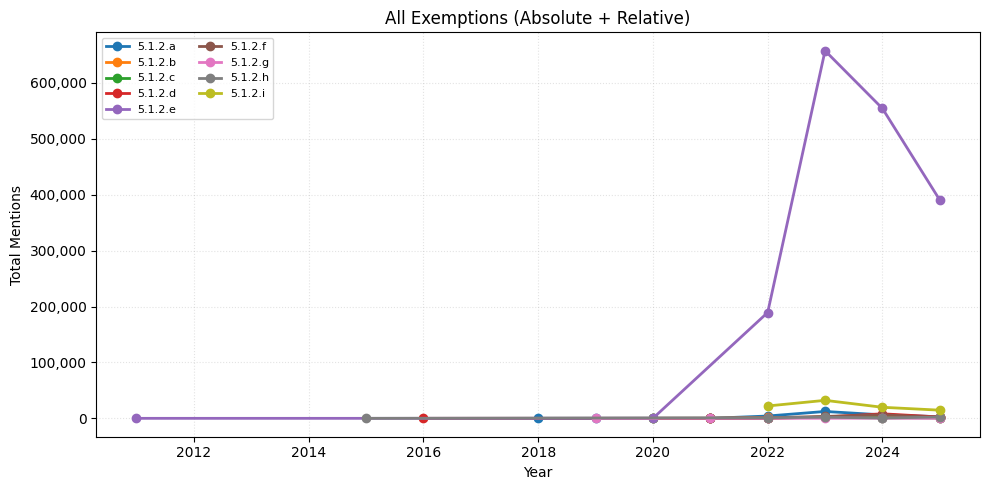


Top 5 most frequently used exemptions:
exemption_ground
5.1.2.e    1791636
5.1.2.i      88717
5.1.2.a      25633
5.1.1.c      20996
5.1.1.b      18227
Name: count, dtype: int64


In [12]:
all_exemptions = ['5.1.2.a', '5.1.2.b', '5.1.2.c', '5.1.2.d', '5.1.2.e',
                       '5.1.2.f', '5.1.2.g', '5.1.2.h', '5.1.2.i']

# Count mentions per exemption type per year
exemption_counts = (
    exemption_results_ministries
    .groupby(['year', 'exemption_ground'])['count']
    .sum()
    .reset_index()
)

# Create a single plot
plt.figure(figsize=(10, 5))

for exemption in all_exemptions:
    data = exemption_counts[exemption_counts['exemption_ground'] == exemption]
    if not data.empty:
        plt.plot(
            data['year'],
            data['count'],
            marker='o',
            linewidth=2,
            markersize=6,
            label=exemption
        )

plt.xlabel('Year')
plt.ylabel('Total Mentions')
plt.title('All Exemptions (Absolute + Relative)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, linestyle=':', alpha=0.35)

plt.gca().yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)

plt.tight_layout()
plt.savefig('exemptions_single_plot.png', bbox_inches='tight')
plt.show()

# Summary table unchanged
print("\nTop 5 most frequently used exemptions:")
top_exemptions = (
    exemption_results_ministries
    .groupby('exemption_ground')['count']
    .sum()
    .sort_values(ascending=False)
    .head()
)
print(top_exemptions)


In [21]:
import plotly.graph_objects as go

# Calculate number of dossiers per ministry per year in exemption_results_ministries
dossiers_with_exemptions = (
    exemption_results_ministries
    .groupby(['dc_publisher_name', 'year'])['foi_documentId']
    .nunique()
    .reset_index()
    .rename(columns={'foi_documentId': 'num_dossiers'})
)

# Filter for years >= 2018 to match other plots
dossiers_with_exemptions = dossiers_with_exemptions[dossiers_with_exemptions['year'] >= 2018]

# Create the interactive plot
fig = go.Figure()

ministries_exemp = sorted(dossiers_with_exemptions['dc_publisher_name'].unique())

# Plot each ministry
for ministry in ministries_exemp:
    ministry_data = dossiers_with_exemptions[
        dossiers_with_exemptions['dc_publisher_name'] == ministry
    ].sort_values('year')
    
    hover_text = [f"Year: {int(year)}<br>Ministry: {ministry}<br>Dossiers: {dossiers:,}" 
                  for year, dossiers in zip(ministry_data['year'], ministry_data['num_dossiers'])]
    
    fig.add_trace(go.Scatter(
        x=ministry_data['year'],
        y=ministry_data['num_dossiers'],
        mode='lines+markers',
        name=ministry,
        hovertext=hover_text,
        hoverinfo='text',
        line=dict(width=2),
        marker=dict(size=6)
    ))

# Overall trend
overall_dossiers = (
    dossiers_with_exemptions
    .groupby('year', as_index=False)['num_dossiers']
    .sum()
    .sort_values('year')
)

if len(overall_dossiers) >= 2:
    slope, intercept = np.polyfit(
        overall_dossiers['year'].astype(float),
        overall_dossiers['num_dossiers'], 1
    )
    trend_y = slope * overall_dossiers['year'] + intercept
    
    fig.add_trace(go.Scatter(
        x=overall_dossiers['year'],
        y=trend_y,
        mode='lines',
        name='Overall trend',
        line=dict(color='black', width=2.2, dash='dash'),
        hoverinfo='skip'
    ))

fig.update_layout(
    title='Number of Dossiers with Exemptions per Ministry Over Time (2018-2025)',
    xaxis_title='Year',
    yaxis_title='Number of Dossiers with Exemptions',
    hovermode='closest',
    height=600,
    width=800,
    legend=dict(font=dict(size=9))
)

fig.show()


In [13]:
# 1. Re-aggregate per year + ministry + exemption
exemption_counts_min = (
    exemption_results_ministries
    .groupby(['year', 'dc_publisher_name', 'exemption_ground'])['count']
    .sum()
    .reset_index()
)

# 2. Total exemptions per year *and* ministry
year_min_totals = (
    exemption_results_ministries
    .groupby(['year', 'dc_publisher_name'])['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'year_total'})
)

# 3. Merge and compute shares (% of all exemptions for that ministry-year)
exemption_share = exemption_counts_min.merge(
    year_min_totals,
    on=['year', 'dc_publisher_name']
)
exemption_share['share'] = (
    exemption_share['count'] / exemption_share['year_total'] * 100
)

all_exemptions = exemption_share['exemption_ground'].unique()

Plot!

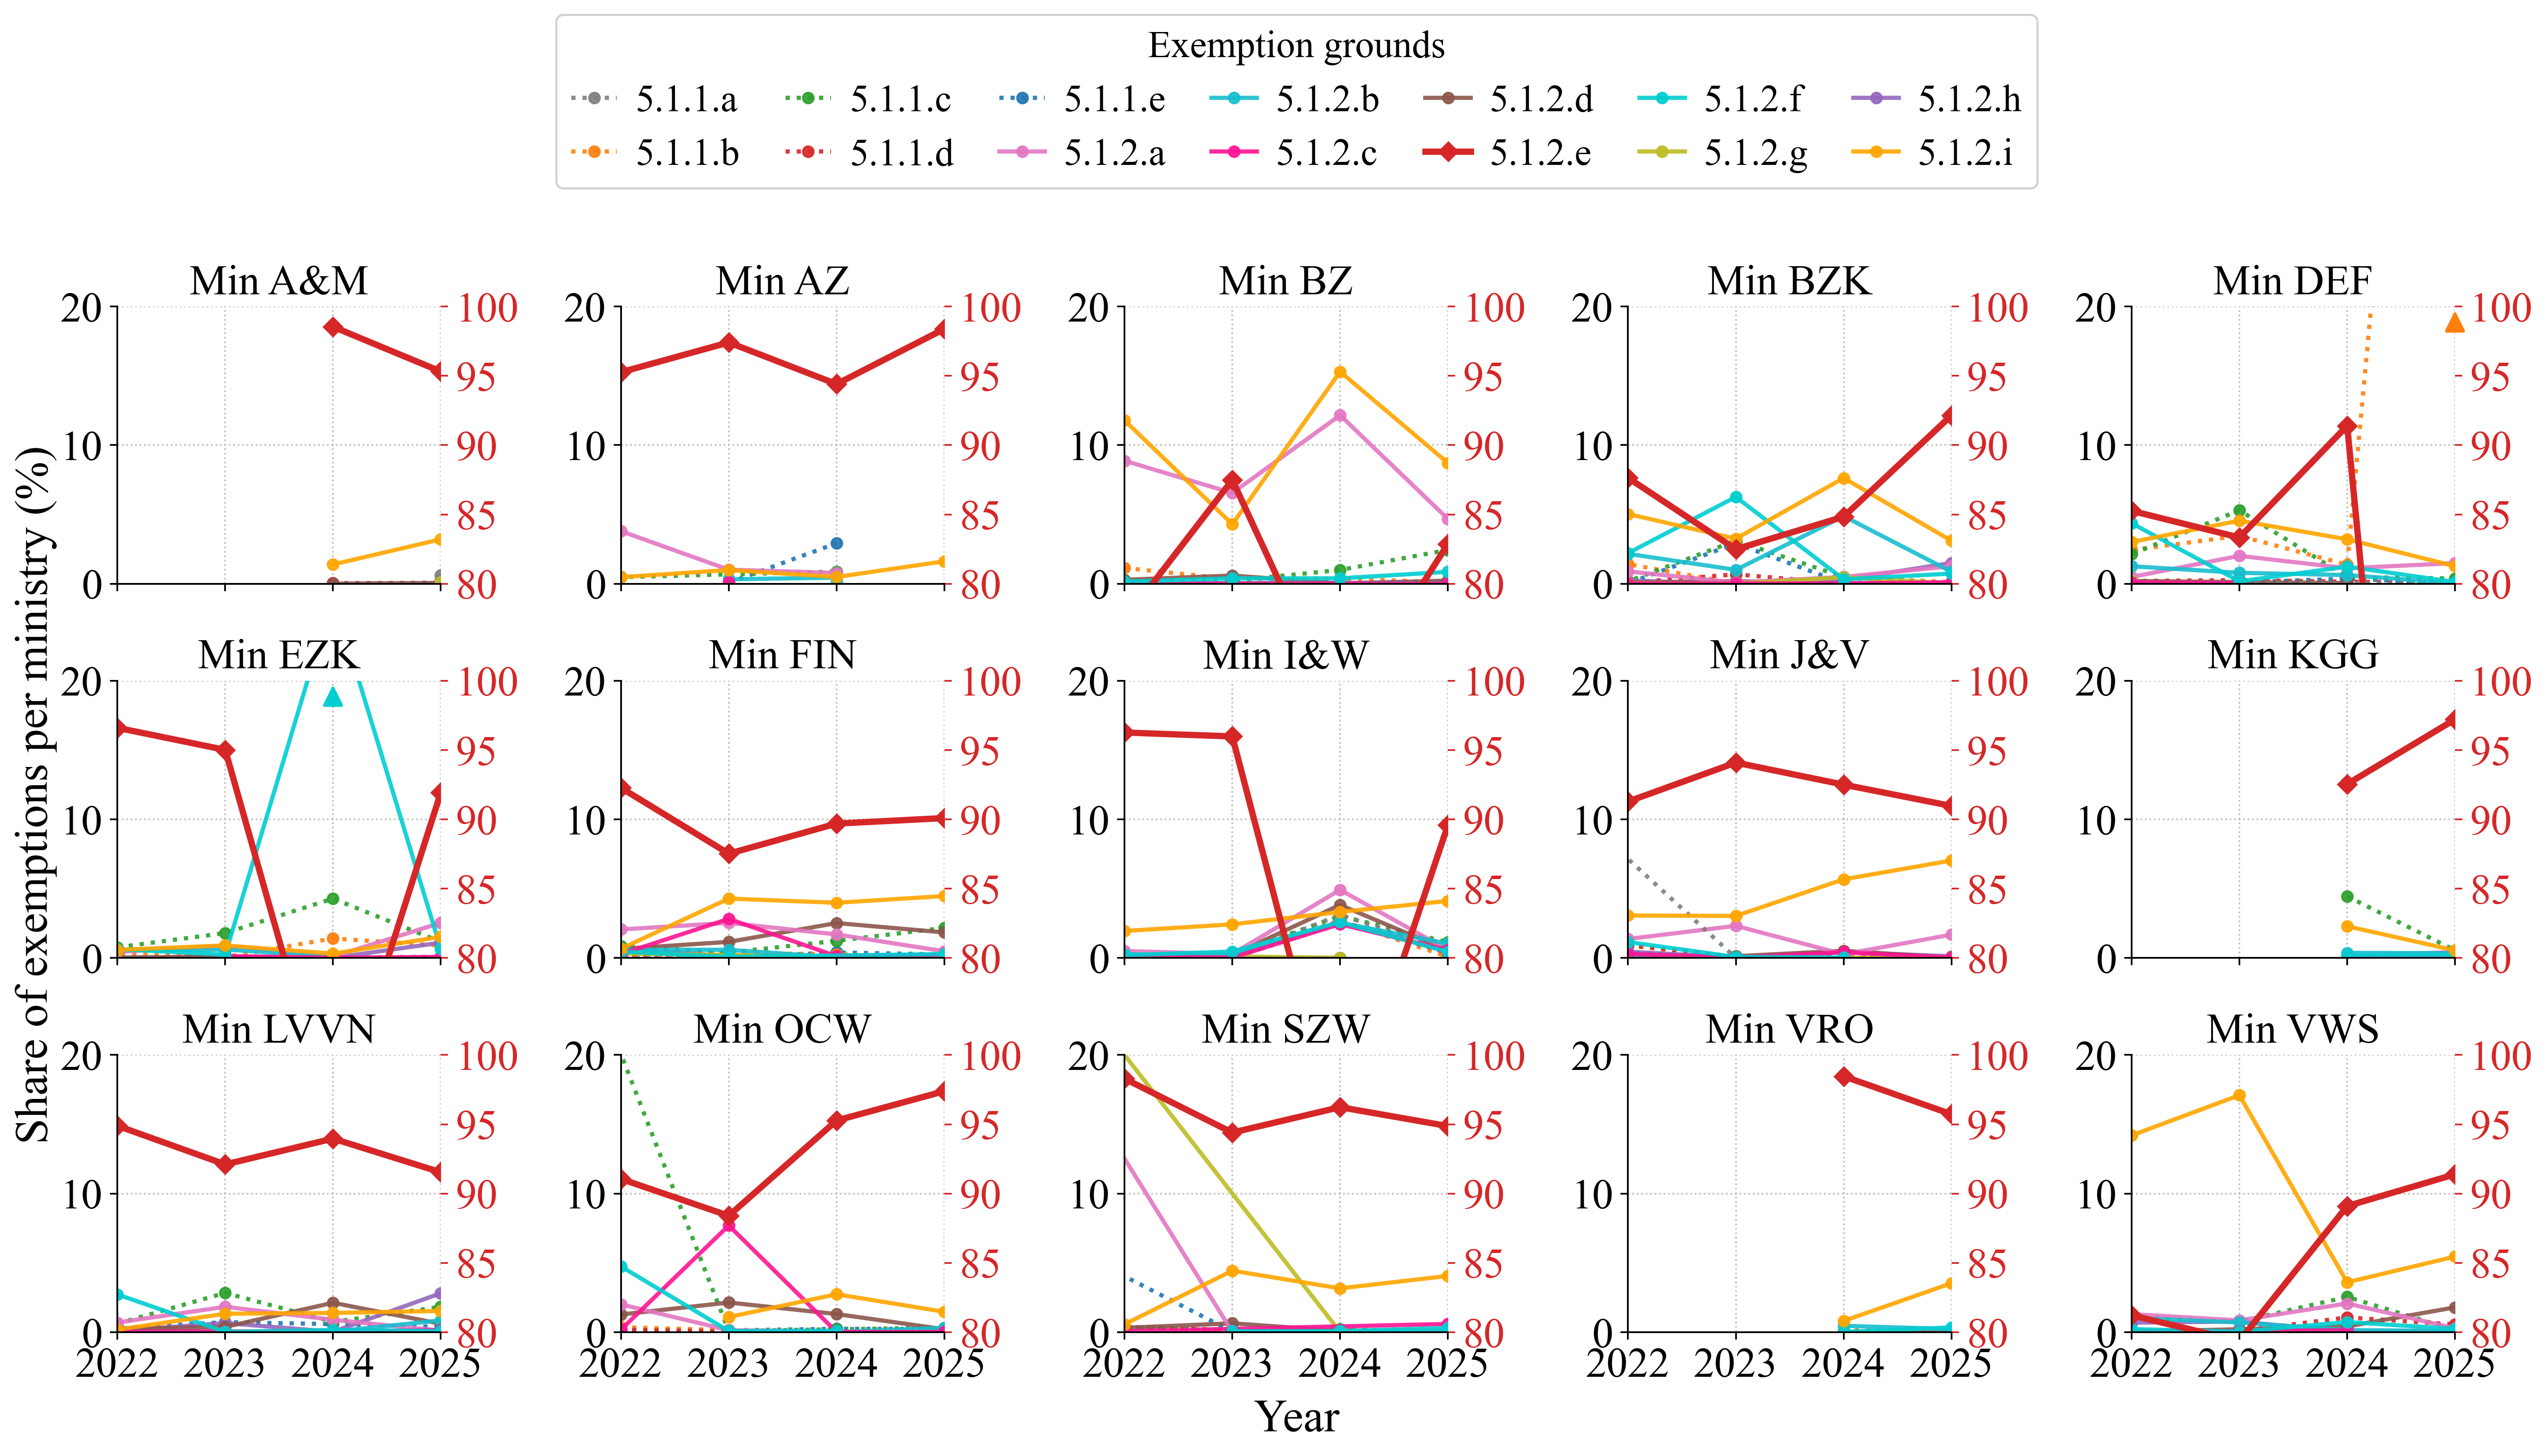

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- GLOBAL SETTINGS ---------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,
})

dominant_exemption = "5.1.2.e"
dominant_color = "tab:red"
plot_exemptions = [e for e in all_exemptions if e != dominant_exemption]

ministries = sorted(exemption_share["dc_publisher_name"].unique())

# Force 2022–2025 for every panel, even if no data
years = list(range(2022, 2026))

primary_ylim = (0, 20)        # y-range for non-dominant exemptions
secondary_ylim = (80, 100)    # y-range for dominant exemption

# Define a more distinguishable color palette
color_palette = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # yellow-green
    '#17becf',  # cyan
    '#ff1493',  # deep pink
    '#00ced1',  # dark turquoise
    '#ffa500',  # orange
]

n_rows, n_cols = 3, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10), sharex=False)
axes = axes.flatten()

global_handles = []
global_labels = []

# --- PLOTTING LOOP ------------------------------------------------------
for i, ministry in enumerate(ministries):
    ax = axes[i]
    mdata = exemption_share[exemption_share["dc_publisher_name"] == ministry]

    # ---- non-dominant exemptions on primary axis ----
    for idx, exemption in enumerate(plot_exemptions):
        data = mdata[mdata["exemption_ground"] == exemption]
        if not data.empty:
            # Use dotted line for 5.1.1.x exemptions, solid for 5.1.2.x
            linestyle = ':' if exemption.startswith('5.1.1') else '-'
            
            h, = ax.plot(
                data["year"], data["share"],
                marker="o", linewidth=2.0, markersize=5, alpha=0.9,
                label=exemption,
                color=color_palette[idx % len(color_palette)],
                linestyle=linestyle
            )

            # Add to global legend once
            if exemption not in global_labels:
                global_handles.append(h)
                global_labels.append(exemption)

            # Overflow arrows for values above primary_ylim
            line_color = h.get_color()
            for x, y in zip(data["year"], data["share"]):
                if y > primary_ylim[1]:
                    ax.annotate(
                        "",
                        xy=(x, primary_ylim[1]),
                        xytext=(x, primary_ylim[1] - 1),
                        arrowprops=dict(
                            arrowstyle="-|>",
                            color=line_color,
                            lw=1.5,
                        ),
                        ha="center",
                    )

    # Panel formatting
    ax.set_title(ministry)
    ax.grid(True, linestyle=":", alpha=0.8)
    ax.set_ylim(*primary_ylim)
    ax.set_ylabel("")  # global y-label instead

    # Force all panels to show 2022–2025 on x-axis
    ax.set_xticks(years)
    ax.set_xlim(2022, 2025)

    # Only bottom row shows year labels
    if i >= (n_rows - 1) * n_cols:
        ax.set_xticklabels([str(y) for y in years])
    else:
        ax.set_xticklabels([])

    # --- dominant exemption on secondary axis ----
    ax2 = ax.twinx()
    dom = mdata[mdata["exemption_ground"] == dominant_exemption]
    if not dom.empty:
        h_dom, = ax2.plot(
            dom["year"], dom["share"],
            color=dominant_color,
            linewidth=3, marker="D", markersize=6,
            label=dominant_exemption,
        )

        if dominant_exemption not in global_labels:
            global_handles.append(h_dom)
            global_labels.append(dominant_exemption)

        # Overflow arrows for dominant exemption
        for x, y in zip(dom["year"], dom["share"]):
            if y > secondary_ylim[1]:
                ax2.annotate(
                    "",
                    xy=(x, secondary_ylim[1]),
                    xytext=(x, secondary_ylim[1] - 0.5),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color=dominant_color,
                        lw=2.0,
                    ),
                    ha="center",
                )

    ax2.set_ylim(*secondary_ylim)

    # Fewer, larger ticks on right y-axis
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(4))  # e.g. ~80, 90, 100
    ax2.tick_params(axis="y", colors=dominant_color, labelsize=20)
    ax2.spines["right"].set_color(dominant_color)
    ax2.grid(False)

# --- GLOBAL LABELS ------------------------------------------------------
fig.text(
    0.03, 0.5,
    "Share of exemptions per ministry (%)",
    va="center", rotation="vertical", fontsize=22,
)
fig.text(0.5, 0.08, "Year", ha="center", fontsize=22)

# --- LAYOUT BEFORE LEGEND (so axes positions are final) -----------------
fig.tight_layout(rect=[0.03, 0.08, 0.97, 0.88])
fig.subplots_adjust(hspace=0.35)

# --- LEGEND: multi-row, shorter line handles, no overlap ----------------
# find top of the grid of axes
top = max(ax.get_position().y1 for ax in axes)

n_legend_cols = 7  # adjust to taste (5–7 usually looks good)
sorted_pairs = sorted(zip(global_labels, global_handles), key=lambda x: x[0])
global_labels, global_handles = zip(*sorted_pairs)
fig.legend(
    global_handles,
    global_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, top + 0.20),  # centered above the grid
    ncol=n_legend_cols,
    framealpha=0.9,
    facecolor="white",
    title="Exemption grounds",
    title_fontsize=18,
    handlelength=1.2,   # shorter line segment -> less intrusion into labels
    handletextpad=0.5,  # gap between handle and text
    columnspacing=1.2,  # gap between columns
    borderaxespad=0.3,
)

plt.savefig("exemptions_ministry_over_time.png", bbox_inches="tight")
plt.show()

### Stale Release


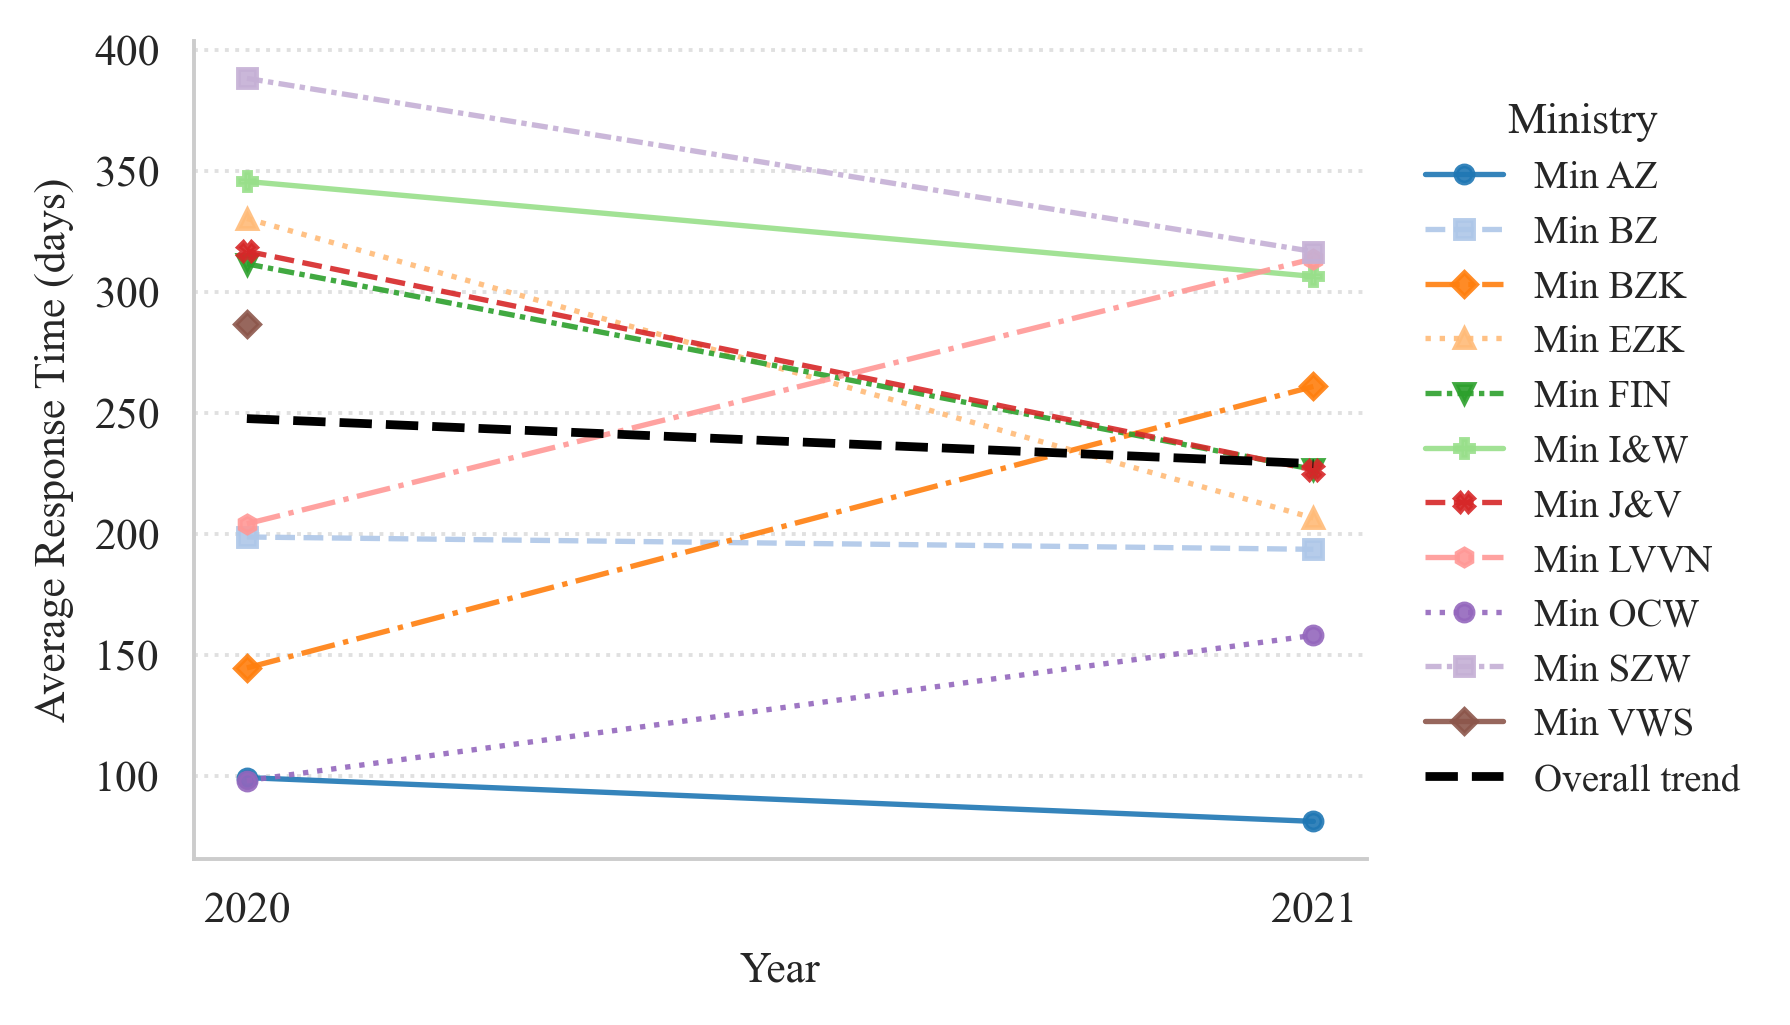

In [236]:
# --- Make plot more compact ---
fig, ax = plt.subplots(figsize=(5.2, 3.0))   # smaller, compact figure

ministries_response = sorted(avg_response_time['dc_publisher_name'].unique())

colors = plt.cm.tab20.colors
linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v", "P", "X", "h"]

# Plot each ministry
for i, ministry in enumerate(ministries_response):
    ministry_data = avg_response_time[
        avg_response_time['dc_publisher_name'] == ministry
    ].sort_values('dc_date_year')
    
    ax.plot(
        ministry_data['dc_date_year'],
        ministry_data['response_days'],
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        linewidth=1.1,
        markersize=3.5,
        alpha=0.9,
        label=ministry
    )

# Trend line
if len(overall_response) >= 2:
    slope, intercept = np.polyfit(
        overall_response['dc_date_year'].astype(float),
        overall_response['response_days'], 1
    )
    trend_y = slope * overall_response['dc_date_year'] + intercept

    ax.plot(
        overall_response['dc_date_year'],
        trend_y,
        color='black',
        linewidth=1.8,
        linestyle='--',
        label='Overall trend'
    )

# Labels and formatting
ax.set_xlabel('Year')
ax.set_ylabel('Average Response Time (days)')

# 👉 Horizontal gridlines (clearer and compact)
ax.yaxis.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
ax.xaxis.grid(False)

# 👉 Only show 2020 and 2021
ax.set_xticks([2020, 2021])
ax.set_xticklabels([2020, 2021])

# Legend (shrink size & move)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=8,
    title='Ministry',
    title_fontsize=9
)

fig.tight_layout()
plt.show()


In [232]:
import plotly.express as px
import numpy as np

# summary as you already computed:
# columns: dc_publisher_name, dc_date_year, response_days,
#          dossiers_this_year, dossiers_total

fig = px.line(
    summary,
    x='dc_date_year',
    y='response_days',
    color='dc_publisher_name',
    markers=True,
    labels={
        'dc_date_year': 'Year',
        'response_days': 'Average Response Time (days)',
        'dc_publisher_name': 'Ministry'
    },
    # these get attached point-by-point:
    custom_data=['dc_publisher_name', 'dossiers_this_year', 'dossiers_total']
)

fig.update_traces(
    hovertemplate=(
        "Ministry: %{customdata[0]}<br>"
        "Year: %{x}<br>"
        "Avg response time: %{y:.1f} days<br>"
        "Dossiers this year: %{customdata[1]}<br>"
        "Total dossiers (2020–2021): %{customdata[2]}<extra></extra>"
    )
)

fig.update_layout(
    legend_title_text='Ministry',
    xaxis_title='Year',
    yaxis_title='Average Response Time (days)',
    hoverlabel=dict(align='left')
)

fig.show()
